# Drug Repurposing Pathfinding Algorithm Benchmark

**Purpose:** Evaluate graph pathfinding algorithms for drug repurposing by comparing predicted mechanistic pathways against curated ground truth pathways.



---

## Setup


In [6]:
# Standard libraries
import pandas as pd
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import heapq
from typing import Dict, List, Tuple
from collections import deque, Counter
from evaluation_helpers import *
from evaluation_metrics import *
from Algorithms import *
from evaluation_runner import run_evaluation
import importlib
import evaluation_visualization as ev
importlib.reload(ev)
from hyperparameter_tuning import (
    run_full_grid_search,
    plot_tuning_results,
    get_best_predictions
)
import os

✓ Evaluation metrics loaded:
  1. precision
  2. recall_at_6_hops
  3. f1_score
  4. path_length_accuracy
  5. hub_node_ratio
  6. mrr
  7. speed
  Use: results, summary = run_evaluation(predictions_dict, ground_truth_nodes, ground_truth_edges, edges)
✓ Evaluation visualization loaded
  Use: generate_full_report(summary)
  Or:  display_summary_table(summary)
✓ Evaluation visualization loaded
  Use: generate_full_report(summary)
  Or:  display_summary_table(summary)
✓ Hyperparameter tuning module loaded
  Use: best_configs, tuning_results = run_full_grid_search(G, ground_truth_nodes, ground_truth_edges, edges)


In [7]:
from pathlib import Path

# Detect repository root (folder that contains "data")
REPO_ROOT = Path.cwd()

# If running from /notebook, move up one level
if not (REPO_ROOT / "data").exists() and (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "data"

PATHS = {
    "nodes": DATA_DIR / "nodes.csv",
    "edges": DATA_DIR / "edges.csv",
    "ground_truth_nodes": DATA_DIR / "benchmark_pathways_nodes.csv",
    "ground_truth_edges": DATA_DIR / "benchmark_pathways_edges.csv",
}

print("Repo root:", REPO_ROOT)
for k, p in PATHS.items():
    print(f"{k}: {p} | exists={p.exists()}")

Repo root: /Users/johncollins/Desktop/PrimeKG-Pathfinding-Algorithm-Benchmark-Laboratory
nodes: /Users/johncollins/Desktop/PrimeKG-Pathfinding-Algorithm-Benchmark-Laboratory/data/nodes.csv | exists=True
edges: /Users/johncollins/Desktop/PrimeKG-Pathfinding-Algorithm-Benchmark-Laboratory/data/edges.csv | exists=True
ground_truth_nodes: /Users/johncollins/Desktop/PrimeKG-Pathfinding-Algorithm-Benchmark-Laboratory/data/benchmark_pathways_nodes.csv | exists=True
ground_truth_edges: /Users/johncollins/Desktop/PrimeKG-Pathfinding-Algorithm-Benchmark-Laboratory/data/benchmark_pathways_edges.csv | exists=True


---
## Load Data

Load the PrimeKG knowledge graph and ground truth pathways.

In [8]:
# Load PrimeKG data
print("Loading PrimeKG data...")
nodes = pd.read_csv(PATHS['nodes'], encoding="latin1")
edges = pd.read_csv(PATHS['edges'], encoding="latin1")

print(f"  Nodes: {len(nodes):,}")
print(f"  Edges: {len(edges):,}")
print(f"  Node types: {nodes['node_type'].nunique()}")
print(f"  Edge types: {edges['relation'].nunique()}")

# Load ground truth
print("\nLoading ground truth pathways...")
ground_truth_nodes = pd.read_csv(PATHS['ground_truth_nodes'], dtype={'node_index': int})
ground_truth_edges = pd.read_csv(PATHS['ground_truth_edges'])

pathways = ground_truth_nodes['pathway_id'].unique()
print(f"  Pathways: {len(pathways)}")
for p in pathways:
    n_nodes = len(ground_truth_nodes[ground_truth_nodes['pathway_id'] == p])
    print(f"    - {p}: {n_nodes} nodes")

Loading PrimeKG data...
  Nodes: 129,375
  Edges: 8,100,498
  Node types: 10
  Edge types: 30

Loading ground truth pathways...
  Pathways: 343
    - valganciclovir_CMV_infection: 3 nodes
    - antazoline_Vasomotor_rhinitis: 3 nodes
    - apalutamide_Nonmetastatic_prostate_cancer: 3 nodes
    - aminoglutethimide_Secondary_malignant_neoplasm_o: 3 nodes
    - anastrozole_Hormone_receptor_positive_mali: 3 nodes
    - diflunisal_Rheumatoid_arthritis: 5 nodes
    - mepyramine_Vasomotor_rhinitis: 3 nodes
    - azilsartan_medoxomil_Hypertensive_disorder: 3 nodes
    - bromocriptine_Hyperprolactinemia: 5 nodes
    - amobarbital_Epilepsy: 6 nodes
    - terbutaline_Asthma: 3 nodes
    - tafamidis_Amyloidosis: 3 nodes
    - FYX-051_Hyperuricemia: 3 nodes
    - FYX-051_Gout: 3 nodes
    - glimepiride_Diabetes_mellitus_type_2: 3 nodes
    - capecitabine_Malignant_tumor_of_stomach: 4 nodes
    - oxaprozin_Rheumatoid_arthritis: 5 nodes
    - pimozide_Gilles_de_la_Tourette's_syndro: 3 nodes
    - clem

In [9]:
# filter
node_counts = ground_truth_nodes.groupby('pathway_id')['node_index'].count()
long_pathways = node_counts[node_counts >= 4].index

ground_truth_nodes = ground_truth_nodes[ground_truth_nodes['pathway_id'].isin(long_pathways)]
ground_truth_edges = ground_truth_edges[ground_truth_edges['pathway_id'].isin(long_pathways)]

print(f"Filtered to {len(long_pathways)} pathways with 4+ nodes")
print(f"  Nodes: {len(ground_truth_nodes):,}")
print(f"  Edges: {len(ground_truth_edges):,}")

Filtered to 150 pathways with 4+ nodes
  Nodes: 877
  Edges: 727


---
## Build Knowledge Graph

Construct a NetworkX directed graph with node/edge attributes for pathfinding.

In [10]:
def build_graph(nodes_df, edges_df, bidirectional=True):
    """
    Build a NetworkX graph from cleaned PrimeKG CSVs.
    
    nodes_df columns:
        node_index, node_id, node_type, node_name, node_source
        
    edges_df columns:
        relation, display_relation, x_index, y_index
    """
    
    G = nx.DiGraph()
    
    # ---------- Add nodes ----------
    for _, row in nodes_df.iterrows():
        G.add_node(
            int(row['node_index']),
            node_id=str(row['node_id']),
            node_name=str(row['node_name']),
            node_type=str(row['node_type']),
            node_source=str(row['node_source'])
        )
    
    # ---------- Add edges ----------
    for _, row in edges_df.iterrows():
        G.add_edge(
            int(row['x_index']),
            int(row['y_index']),
            relation=str(row['relation']),
            display_relation=str(row['display_relation'])
        )
        
        if bidirectional:
            G.add_edge(
                int(row['y_index']),
                int(row['x_index']),
                relation=str(row['relation']),
                display_relation=str(row['display_relation'])
            )
    
    return G

print("Building graph...")
G = build_graph(nodes, edges, bidirectional=True)
print(f"Graph built: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Building graph...
Graph built: 129,375 nodes, 8,099,284 edges


---
## Algorithm 1 - Shortest Path Baseline

The simplest baseline: find the shortest path (by hop count) between drug and disease.

**Expected behavior:**
- ✅ Will always find the target disease (if connected)
- ❌ May take shortcuts through direct drug→disease edges
- ❌ Ignores edge types and biological mechanism

In [11]:
def run_shortest_path(graph, ground_truth_df):
    """
    Run shortest path algorithm on all pathways.
    
    Returns:
        DataFrame with predictions for each pathway
    """
    results = []
    
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        
        # Get source (drug) and target (disease) indices
        source_idx = int(pathway_df.iloc[0]['node_index'])
        target_idx = int(pathway_df.iloc[-1]['node_index'])
        
        source_name = pathway_df.iloc[0]['node_name']
        target_name = pathway_df.iloc[-1]['node_name']
        
        print(f"\n{pathway_id}: {source_name} → {target_name}")
        
        try:
            # Find shortest path
            predicted_path = nx.shortest_path(graph, source_idx, target_idx)
            predicted_node_ids = [graph.nodes[idx]['node_id'] for idx in predicted_path]
            predicted_node_names = [graph.nodes[idx]['node_name'] for idx in predicted_path]
            
            # Get edge relations along path
            predicted_relations = []
            for i in range(len(predicted_path) - 1):
                edge_data = graph.get_edge_data(predicted_path[i], predicted_path[i+1])
                predicted_relations.append(edge_data['relation'])
            
            print(f"  ✓ Found path: {len(predicted_path)} nodes")
            print(f"  Path: {' → '.join(predicted_node_names[:5])}{'...' if len(predicted_path) > 5 else ''}")
            
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': ','.join(map(str, predicted_path)),
                'predicted_node_ids': ','.join(predicted_node_ids),
                'predicted_node_names': ','.join(predicted_node_names),
                'predicted_relations': ','.join(predicted_relations),
                'predicted_length': len(predicted_path),
                'ground_truth_length': len(pathway_df)
            })
            
        except nx.NetworkXNoPath:
            print(f"  ✗ No path found")
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': 'NONE',
                'predicted_node_ids': 'NONE',
                'predicted_node_names': 'NONE',
                'predicted_relations': 'NONE',
                'predicted_length': 0,
                'ground_truth_length': len(pathway_df)
            })
    
    return pd.DataFrame(results)


# Run shortest path
print("="*60)
print("Running Shortest Path Algorithm")
print("="*60)

sp_predictions = run_shortest_path(G, ground_truth_nodes)
# sp_predictions.to_csv('baseline_shortest_path_predictions.csv', index=False)
# print("\n✓ Saved: baseline_shortest_path_predictions.csv")

Running Shortest Path Algorithm

diflunisal_Rheumatoid_arthritis: diflunisal → Rheumatoid arthritis
  ✓ Found path: 2 nodes
  Path: Diflunisal → rheumatoid arthritis

bromocriptine_Hyperprolactinemia: bromocriptine → Hyperprolactinemia
  ✓ Found path: 2 nodes
  Path: Bromocriptine → hyperprolactinemia (disease)

amobarbital_Epilepsy: amobarbital → Epilepsy
  ✓ Found path: 2 nodes
  Path: Amobarbital → epilepsy

capecitabine_Malignant_tumor_of_stomach: Capecitabine → Malignant tumor of stomach
  ✓ Found path: 2 nodes
  Path: Capecitabine → gastric neoplasm

oxaprozin_Rheumatoid_arthritis: oxaprozin → Rheumatoid arthritis
  ✓ Found path: 2 nodes
  Path: Oxaprozin → rheumatoid arthritis

regorafenib_Gastrointestinal_stromal_tumor: regorafenib → Gastrointestinal stromal tumor
  ✓ Found path: 2 nodes
  Path: Regorafenib → gastrointestinal stromal tumor

abiraterone_acetate_Malignant_tumor_of_prostate: abiraterone acetate → Malignant tumor of prostate
  ✓ Found path: 3 nodes
  Path: Abirater

---
## Meta-Path Constrained BFS

An improved baseline that enforces biologically valid edge type sequences.

**Valid meta-path patterns:**
1. `drug → protein → disease` (direct mechanism)
2. `drug → protein → protein → disease` (protein interactions)
3. `drug → protein → anatomy → protein → disease` (tissue-specific)

**Invalid shortcuts blocked:**
- ❌ `drug → disease` (clinical indication, not mechanism)
- ❌ `drug → drug → disease` (drug similarity)

In [12]:
# Define valid meta-path patterns (edge type sequences)
VALID_METAPATHS = [
    # Pattern 1: Direct protein mechanism (drug → protein → disease)
    ['drug_protein', 'disease_protein'],
    
    # Pattern 2: Protein-protein interaction
    ['drug_protein', 'protein_protein', 'disease_protein'],
    
    # Pattern 3: Multiple protein interactions
    ['drug_protein', 'protein_protein', 'protein_protein', 'disease_protein'],
    
    # Pattern 4: Pathway-mediated
    ['drug_protein', 'pathway_protein', 'disease_protein'],
    ['drug_protein', 'pathway_protein', 'pathway_protein', 'disease_protein'],
    ['drug_protein', 'pathway_protein', 'pathway_pathway', 'pathway_protein', 'disease_protein'],
    
    # Pattern 5: Anatomy-mediated (tissue-specific)
    ['drug_protein', 'anatomy_protein_present', 'anatomy_protein_present', 'disease_protein'],
    
    # Pattern 6: Complex pathways
    ['drug_protein', 'protein_protein', 'pathway_protein', 'disease_protein'],
    ['drug_protein', 'pathway_protein', 'pathway_protein', 'pathway_protein', 'disease_protein'],
]

print(f"Defined {len(VALID_METAPATHS)} valid meta-path patterns:")
for i, pattern in enumerate(VALID_METAPATHS, 1):
    print(f"  {i}. {' → '.join(pattern)}")

Defined 9 valid meta-path patterns:
  1. drug_protein → disease_protein
  2. drug_protein → protein_protein → disease_protein
  3. drug_protein → protein_protein → protein_protein → disease_protein
  4. drug_protein → pathway_protein → disease_protein
  5. drug_protein → pathway_protein → pathway_protein → disease_protein
  6. drug_protein → pathway_protein → pathway_pathway → pathway_protein → disease_protein
  7. drug_protein → anatomy_protein_present → anatomy_protein_present → disease_protein
  8. drug_protein → protein_protein → pathway_protein → disease_protein
  9. drug_protein → pathway_protein → pathway_protein → pathway_protein → disease_protein


In [13]:
def is_valid_metapath(relations, valid_metapaths):
    """Check if a relation sequence matches any valid meta-path pattern."""
    return relations in valid_metapaths


def could_match_metapath(relations, valid_metapaths):
    """Check if the current relation sequence could potentially lead to a valid path."""
    for pattern in valid_metapaths:
        if len(relations) <= len(pattern):
            if relations == pattern[:len(relations)]:
                return True
    return False


def metapath_constrained_bfs(source_idx, target_idx, graph, valid_metapaths, max_length=10):
    """
    Find shortest path that follows valid meta-path patterns.
    
    Uses BFS but only explores edges that could lead to a valid meta-path.
    
    Returns:
        (path_nodes, path_relations) or ([], []) if no valid path found
    """
    # Queue: (current_node, path_so_far, relations_so_far)
    queue = deque([(source_idx, [source_idx], [])])
    visited = {source_idx: []}  # Track visited states with relation sequences
    
    while queue:
        current_node, path, relations = queue.popleft()
        
        # Check if we reached target with valid meta-path
        if current_node == target_idx:
            if is_valid_metapath(relations, valid_metapaths):
                return path, relations
        
        # Stop if path too long
        if len(path) >= max_length:
            continue
        
        # Explore neighbors
        for neighbor in graph.neighbors(current_node):
            edge_data = graph.get_edge_data(current_node, neighbor)
            new_relation = edge_data['relation']
            new_relations = relations + [new_relation]
            
            # Only continue if this could lead to a valid meta-path
            if could_match_metapath(new_relations, valid_metapaths):
                state_key = (neighbor, tuple(new_relations))
                
                # Avoid revisiting same state
                if neighbor not in visited or visited[neighbor] != new_relations:
                    visited[neighbor] = new_relations
                    queue.append((neighbor, path + [neighbor], new_relations))
    
    return [], []  # No valid path found


def run_metapath_algorithm(graph, ground_truth_df, valid_metapaths):
    """
    Run meta-path constrained BFS on all pathways.
    """
    results = []
    
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        
        source_idx = int(pathway_df.iloc[0]['node_index'])
        target_idx = int(pathway_df.iloc[-1]['node_index'])
        
        source_name = pathway_df.iloc[0]['node_name']
        target_name = pathway_df.iloc[-1]['node_name']
        
        gt_path = ' → '.join(pathway_df['node_name'].tolist())
        
        print(f"\n{pathway_id}: {source_name} → {target_name}")
        
        # Find meta-path constrained path
        predicted_path, predicted_relations = metapath_constrained_bfs(
            source_idx, target_idx, graph, valid_metapaths
        )
        
        if predicted_path:
            predicted_node_ids = [graph.nodes[idx]['node_id'] for idx in predicted_path]
            predicted_node_names = [graph.nodes[idx]['node_name'] for idx in predicted_path]
            
            print(f"  ✓ Found valid path: {len(predicted_path)} nodes")
            print(f"  Meta-path: {' → '.join(predicted_relations)}")
            print(f"  Path: {' → '.join(predicted_node_names)}")
            print(f"  Ground truth: {gt_path}")
            
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': ','.join(map(str, predicted_path)),
                'predicted_node_ids': ','.join(predicted_node_ids),
                'predicted_node_names': ','.join(predicted_node_names),
                'predicted_relations': ','.join(predicted_relations),
                'predicted_length': len(predicted_path),
                'ground_truth_length': len(pathway_df)
            })
        else:
            print(f"  ✗ No valid meta-path found")
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': 'NONE',
                'predicted_node_ids': 'NONE',
                'predicted_node_names': 'NONE',
                'predicted_relations': 'NONE',
                'predicted_length': 0,
                'ground_truth_length': len(pathway_df)
            })
    
    return pd.DataFrame(results)


# Run meta-path algorithm
print("="*60)
print("Running Meta-Path Constrained Algorithm")
print("="*60)

mp_predictions = run_metapath_algorithm(G, ground_truth_nodes, VALID_METAPATHS)
# mp_predictions.to_csv('baseline_metapath_predictions.csv', index=False)
# print("\n✓ Saved: baseline_metapath_predictions.csv")

Running Meta-Path Constrained Algorithm

diflunisal_Rheumatoid_arthritis: diflunisal → Rheumatoid arthritis
  ✓ Found valid path: 3 nodes
  Meta-path: drug_protein → disease_protein
  Path: Diflunisal → PTGS1 → rheumatoid arthritis
  Ground truth: diflunisal → Prostaglandin G/H synthase 2 → inflammatory response → Prostaglandin G/H synthase 1 → Rheumatoid arthritis

bromocriptine_Hyperprolactinemia: bromocriptine → Hyperprolactinemia
  ✓ Found valid path: 3 nodes
  Meta-path: drug_protein → disease_protein
  Path: Bromocriptine → DRD2 → hyperprolactinemia (disease)
  Ground truth: bromocriptine → Dopamine D3 receptor → dopamine → Dopamine D2 receptor → Hyperprolactinemia

amobarbital_Epilepsy: amobarbital → Epilepsy
  ✓ Found valid path: 3 nodes
  Meta-path: drug_protein → disease_protein
  Path: Amobarbital → GABRA5 → epilepsy
  Ground truth: amobarbital → Gamma-aminobutyric acid receptor subunit alpha-2 → GABA-gated chloride ion channel activity → Gamma-aminobutyric acid receptor sub

## Algorithm 2: Hub-Penalized Weighted Shortest Path

**Core Idea:** High-degree "hub" nodes (like inflammation markers) connect to everything but don't represent specific mechanisms. Penalize them.

**Weight Formula:** `weight[u,v] = 1 + α * log(degree[v])`

- α = 0.5 is a good default (can be tuned)
- Higher degree → higher weight → less preferred

In [14]:
# ============================================================
# ALGORITHM 2: Hub-Penalized Weighted Shortest Path
# ============================================================


def run_hub_penalized(graph, ground_truth_df, alpha=0.5):
    """
    Run Hub-Penalized algorithm on all pathways.
    """
    results = []
    
    # Initialize algorithm
    print("Initializing Hub-Penalized algorithm...")
    algo = HubPenalizedShortestPath(graph, alpha=alpha)
    print(f"  Edge weights computed (α={alpha})")
    
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        
        source_idx = int(pathway_df.iloc[0]['node_index'])
        target_idx = int(pathway_df.iloc[-1]['node_index'])
        source_name = pathway_df.iloc[0]['node_name']
        target_name = pathway_df.iloc[-1]['node_name']
        
        print(f"\n{pathway_id}: {source_name} → {target_name}")
        
        path, relations, weight = algo.find_path(source_idx, target_idx)
        
        if path:
            node_ids = [graph.nodes[idx].get('node_id', str(idx)) for idx in path]
            node_names = [graph.nodes[idx].get('node_name', str(idx)) for idx in path]
            
            print(f"  ✓ Found path: {len(path)} nodes")
            print(f"  Path: {' → '.join(node_names)}")
            
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': ','.join(map(str, path)),
                'predicted_node_ids': ','.join(node_ids),
                'predicted_node_names': ','.join(node_names),
                'predicted_relations': ','.join(relations),
                'predicted_length': len(path),
                'ground_truth_length': len(pathway_df)
            })
        else:
            print(f"  ✗ No path found")
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': 'NONE',
                'predicted_node_ids': 'NONE',
                'predicted_node_names': 'NONE',
                'predicted_relations': 'NONE',
                'predicted_length': 0,
                'ground_truth_length': len(pathway_df)
            })
    
    return pd.DataFrame(results)


# Run Algorithm 2
print("="*60)
print("Running Hub-Penalized Algorithm")
print("="*60)

hub_predictions = run_hub_penalized(G, ground_truth_nodes, alpha=0.5)
# hub_predictions.to_csv('hub_penalized_predictions.csv', index=False)
# print("\n✓ Saved: hub_penalized_predictions.csv")

Running Hub-Penalized Algorithm
Initializing Hub-Penalized algorithm...
  Edge weights computed (α=0.5)

diflunisal_Rheumatoid_arthritis: diflunisal → Rheumatoid arthritis
  ✓ Found path: 3 nodes
  Path: Diflunisal → PTGS1 → rheumatoid arthritis

bromocriptine_Hyperprolactinemia: bromocriptine → Hyperprolactinemia
  ✓ Found path: 3 nodes
  Path: Bromocriptine → DRD2 → hyperprolactinemia (disease)

amobarbital_Epilepsy: amobarbital → Epilepsy
  ✓ Found path: 3 nodes
  Path: Amobarbital → CHRNA4 → epilepsy

capecitabine_Malignant_tumor_of_stomach: Capecitabine → Malignant tumor of stomach
  ✓ Found path: 3 nodes
  Path: Capecitabine → TYMP → gastric neoplasm

oxaprozin_Rheumatoid_arthritis: oxaprozin → Rheumatoid arthritis
  ✓ Found path: 3 nodes
  Path: Oxaprozin → Vasculitis → rheumatoid arthritis

regorafenib_Gastrointestinal_stromal_tumor: regorafenib → Gastrointestinal stromal tumor
  ✓ Found path: 3 nodes
  Path: Regorafenib → PDGFRA → gastrointestinal stromal tumor

abiraterone_ac

In [15]:
#tuning


## Algorithm 3: PageRank-Inverse Weighted Shortest Path

**Core Idea:** PageRank captures global graph centrality. Nodes with HIGH PageRank are generic hubs. We want paths through LOW PageRank (more specific) nodes.

**Weight Formula:** `weight[u,v] = 1 / (1 + pagerank[v])`

- Low PageRank → low weight → preferred
- PageRank is computed once upfront

In [16]:
# ============================================================
# ALGORITHM 3: PageRank-Inverse Weighted Shortest Path
# ============================================================

def run_pagerank_inverse(graph, ground_truth_df, damping=0.85):
    """
    Run PageRank-Inverse algorithm on all pathways.
    """
    results = []
    
    # Initialize algorithm
    print("Initializing PageRank-Inverse algorithm...")
    algo = PageRankInverseShortestPath(graph, damping=damping)
    print(f"  Edge weights computed")
    
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        
        source_idx = int(pathway_df.iloc[0]['node_index'])
        target_idx = int(pathway_df.iloc[-1]['node_index'])
        source_name = pathway_df.iloc[0]['node_name']
        target_name = pathway_df.iloc[-1]['node_name']
        
        print(f"\n{pathway_id}: {source_name} → {target_name}")
        
        path, relations, weight = algo.find_path(source_idx, target_idx)
        
        if path:
            node_ids = [graph.nodes[idx].get('node_id', str(idx)) for idx in path]
            node_names = [graph.nodes[idx].get('node_name', str(idx)) for idx in path]
            
            print(f"  ✓ Found path: {len(path)} nodes")
            print(f"  Path: {' → '.join(node_names)}")
            
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': ','.join(map(str, path)),
                'predicted_node_ids': ','.join(node_ids),
                'predicted_node_names': ','.join(node_names),
                'predicted_relations': ','.join(relations),
                'predicted_length': len(path),
                'ground_truth_length': len(pathway_df)
            })
        else:
            print(f"  ✗ No path found")
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': 'NONE',
                'predicted_node_ids': 'NONE',
                'predicted_node_names': 'NONE',
                'predicted_relations': 'NONE',
                'predicted_length': 0,
                'ground_truth_length': len(pathway_df)
            })
    
    return pd.DataFrame(results)


# Run Algorithm 3
print("="*60)
print("Running PageRank-Inverse Algorithm")
print("="*60)

pr_predictions = run_pagerank_inverse(G, ground_truth_nodes, damping=0.85)
# pr_predictions.to_csv('pagerank_inverse_predictions.csv', index=False)
# print("\n✓ Saved: pagerank_inverse_predictions.csv")

Running PageRank-Inverse Algorithm
Initializing PageRank-Inverse algorithm...
  Computing PageRank (this may take a minute)...
  PageRank computed for 129,375 nodes
  Edge weights computed

diflunisal_Rheumatoid_arthritis: diflunisal → Rheumatoid arthritis
  ✓ Found path: 3 nodes
  Path: Diflunisal → Fever → rheumatoid arthritis

bromocriptine_Hyperprolactinemia: bromocriptine → Hyperprolactinemia
  ✓ Found path: 3 nodes
  Path: Bromocriptine → DRD2 → hyperprolactinemia (disease)

amobarbital_Epilepsy: amobarbital → Epilepsy
  ✓ Found path: 3 nodes
  Path: Amobarbital → CHRNA7 → epilepsy

capecitabine_Malignant_tumor_of_stomach: Capecitabine → Malignant tumor of stomach
  ✓ Found path: 3 nodes
  Path: Capecitabine → TYMS → gastric neoplasm

oxaprozin_Rheumatoid_arthritis: oxaprozin → Rheumatoid arthritis
  ✓ Found path: 3 nodes
  Path: Oxaprozin → Fever → rheumatoid arthritis

regorafenib_Gastrointestinal_stromal_tumor: regorafenib → Gastrointestinal stromal tumor
  ✓ Found path: 3 nod

## Algorithm 4: Learned Embeddings + A* with Supervised Edge Weights

**Core Idea:** Learn from known drug repurposing pathways what makes a "good" edge.

**Two Phases:**
1. **Embed:** Train Node2Vec (or use spectral embeddings) to capture graph structure
2. **Learn:** Train MLP to predict edge goodness from:
   - Embedding similarity
   - Degree features
   - Edge type

**Search:** A* with learned weights + embedding-based heuristic

In [17]:
# ============================================================
# ALGORITHM 4: Learned Embeddings + A* with Supervised Edge Weights
# ============================================================

def run_learned_astar(graph, ground_truth_df, embedding_dim=64):
    """
    Run Learned Embeddings + A* algorithm on all pathways.
    """
    results = []
    
    # Initialize algorithm
    print("Initializing Learned Embeddings + A* algorithm...")
    algo = LearnedEmbeddingsAStar(graph, embedding_dim=embedding_dim)
    algo.train_embeddings()
    
    # Prepare training data from ground truth
    training_pathways = []
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        training_pathways.append({'path_nodes': pathway_df['node_index'].tolist()})
    
    algo.train_edge_weights(training_pathways)
    
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        
        source_idx = int(pathway_df.iloc[0]['node_index'])
        target_idx = int(pathway_df.iloc[-1]['node_index'])
        source_name = pathway_df.iloc[0]['node_name']
        target_name = pathway_df.iloc[-1]['node_name']
        
        print(f"\n{pathway_id}: {source_name} → {target_name}")
        
        path, relations, weight = algo.find_path(source_idx, target_idx)
        
        if path:
            node_ids = [graph.nodes[idx].get('node_id', str(idx)) for idx in path]
            node_names = [graph.nodes[idx].get('node_name', str(idx)) for idx in path]
            
            print(f"  ✓ Found path: {len(path)} nodes")
            print(f"  Path: {' → '.join(node_names)}")
            
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': ','.join(map(str, path)),
                'predicted_node_ids': ','.join(node_ids),
                'predicted_node_names': ','.join(node_names),
                'predicted_relations': ','.join(relations),
                'predicted_length': len(path),
                'ground_truth_length': len(pathway_df)
            })
        else:
            print(f"  ✗ No path found")
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': 'NONE',
                'predicted_node_ids': 'NONE',
                'predicted_node_names': 'NONE',
                'predicted_relations': 'NONE',
                'predicted_length': 0,
                'ground_truth_length': len(pathway_df)
            })
    
    return pd.DataFrame(results)


# Run Algorithm 4
print("="*60)
print("Running Learned Embeddings + A* Algorithm")
print("="*60)

learned_predictions = run_learned_astar(G, ground_truth_nodes, embedding_dim=64)
# learned_predictions.to_csv('learned_astar_predictions.csv', index=False)
# print("\n✓ Saved: learned_astar_predictions.csv")

Running Learned Embeddings + A* Algorithm
Initializing Learned Embeddings + A* algorithm...
Computing spectral embeddings (sparse method)...
  Embeddings computed for 129,375 nodes
  Training edge weight MLP...
  MLP trained on 1232 samples (R²=0.637)
  Precomputing edge weights...
  Edge weights computed for 8,099,284 edges

diflunisal_Rheumatoid_arthritis: diflunisal → Rheumatoid arthritis
  ✓ Found path: 9 nodes
  Path: Diflunisal → PTGS2 → dorsal root ganglion → UBC → zone of skin → APP → Cerebral hemorrhage → MMP2 → rheumatoid arthritis

bromocriptine_Hyperprolactinemia: bromocriptine → Hyperprolactinemia
  ✓ Found path: 3 nodes
  Path: Bromocriptine → DRD2 → hyperprolactinemia (disease)

amobarbital_Epilepsy: amobarbital → Epilepsy
  ✓ Found path: 5 nodes
  Path: Amobarbital → CHRNA4 → Varenicline → CHRNA3 → epilepsy

capecitabine_Malignant_tumor_of_stomach: Capecitabine → Malignant tumor of stomach
  ✓ Found path: 10 nodes
  Path: Capecitabine → CES1 → Oseltamivir → ABCC4 → Ator

## Algorithm 5: Semantic Bridging with Intermediate Node Scoring

**Core Idea:** Use NLP to find paths where consecutive nodes are semantically related (they "make sense" together).

**Weight Formula:** `weight[u,v] = 1 - β * cosine_sim(text_emb[u], text_emb[v])`

- β = 0.3 balances semantic preference with path length
- Uses TF-IDF embeddings (or SciBERT if available)

In [18]:
# ============================================================
# ALGORITHM 5: Semantic Bridging with Intermediate Node Scoring
# ============================================================

def run_semantic_bridging(graph, ground_truth_df, beta=0.3):
    """
    Run Semantic Bridging algorithm on all pathways.
    """
    results = []
    
    # Initialize algorithm
    print("Initializing Semantic Bridging algorithm...")
    algo = SemanticBridgingPath(graph, beta=beta)
    algo.compute_embeddings()
    algo.compute_edge_weights()
    
    for pathway_id in ground_truth_df['pathway_id'].unique():
        pathway_df = ground_truth_df[ground_truth_df['pathway_id'] == pathway_id].sort_values('step_order')
        
        source_idx = int(pathway_df.iloc[0]['node_index'])
        target_idx = int(pathway_df.iloc[-1]['node_index'])
        source_name = pathway_df.iloc[0]['node_name']
        target_name = pathway_df.iloc[-1]['node_name']
        
        print(f"\n{pathway_id}: {source_name} → {target_name}")
        
        path, relations, weight = algo.find_path(source_idx, target_idx)
        
        if path:
            node_ids = [graph.nodes[idx].get('node_id', str(idx)) for idx in path]
            node_names = [graph.nodes[idx].get('node_name', str(idx)) for idx in path]
            
            print(f"  ✓ Found path: {len(path)} nodes")
            print(f"  Path: {' → '.join(node_names)}")
            
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': ','.join(map(str, path)),
                'predicted_node_ids': ','.join(node_ids),
                'predicted_node_names': ','.join(node_names),
                'predicted_relations': ','.join(relations),
                'predicted_length': len(path),
                'ground_truth_length': len(pathway_df)
            })
        else:
            print(f"  ✗ No path found")
            results.append({
                'pathway_id': pathway_id,
                'predicted_node_indices': 'NONE',
                'predicted_node_ids': 'NONE',
                'predicted_node_names': 'NONE',
                'predicted_relations': 'NONE',
                'predicted_length': 0,
                'ground_truth_length': len(pathway_df)
            })
    
    return pd.DataFrame(results)


# Run Algorithm 5
print("="*60)
print("Running Semantic Bridging Algorithm")
print("="*60)

semantic_predictions = run_semantic_bridging(G, ground_truth_nodes, beta=0.3)
# semantic_predictions.to_csv('semantic_bridging_predictions.csv', index=False)
# print("\n✓ Saved: semantic_bridging_predictions.csv")

Running Semantic Bridging Algorithm
Initializing Semantic Bridging algorithm...
  Computing TF-IDF embeddings...
  Embeddings computed for 129,375 nodes
  Computing edge weights...
  Edge weights computed for 8,099,284 edges

diflunisal_Rheumatoid_arthritis: diflunisal → Rheumatoid arthritis
  ✓ Found path: 3 nodes
  Path: Diflunisal → PTGS2 → rheumatoid arthritis

bromocriptine_Hyperprolactinemia: bromocriptine → Hyperprolactinemia
  ✓ Found path: 3 nodes
  Path: Bromocriptine → DRD2 → hyperprolactinemia (disease)

amobarbital_Epilepsy: amobarbital → Epilepsy
  ✓ Found path: 3 nodes
  Path: Amobarbital → GABRA5 → epilepsy

capecitabine_Malignant_tumor_of_stomach: Capecitabine → Malignant tumor of stomach
  ✓ Found path: 3 nodes
  Path: Capecitabine → TYMS → gastric neoplasm

oxaprozin_Rheumatoid_arthritis: oxaprozin → Rheumatoid arthritis
  ✓ Found path: 3 nodes
  Path: Oxaprozin → Vasculitis → rheumatoid arthritis

regorafenib_Gastrointestinal_stromal_tumor: regorafenib → Gastrointes

---
## Evaluate Algorithms

Calculate all 9 metrics for both algorithms and compare.

In [19]:
predictions_dict = {
    'Dijkstra': sp_predictions,
    'Meta-Path': mp_predictions,
    'Hub-Penalized': hub_predictions,
    'PageRank-Inverse': pr_predictions,
    'Semantic-Bridging': semantic_predictions,
}

print(edges.columns.tolist())

results, summary = run_evaluation(
    predictions_dict=predictions_dict,
    ground_truth_nodes=ground_truth_nodes,
    ground_truth_edges=ground_truth_edges,
    edges_df=edges
)

# 用新的 visualization
ev.display_summary_table(summary)


# results.to_csv('evaluation_results.csv', index=False)
# summary.to_csv('evaluation_summary.csv')


['relation', 'display_relation', 'x_index', 'y_index']
RUNNING EVALUATION PIPELINE

1. Computing node degrees...
   ✓ Computed degrees for 129,375 nodes

2. Computing hub threshold...
   ✓ Hub threshold (95th percentile): 412

3. Evaluating algorithms...
Evaluating Dijkstra...
  ✓ 150 pathways evaluated
Evaluating Meta-Path...
  ✓ 150 pathways evaluated
Evaluating Hub-Penalized...
  ✓ 150 pathways evaluated
Evaluating PageRank-Inverse...
  ✓ 150 pathways evaluated
Evaluating Semantic-Bridging...
  ✓ 150 pathways evaluated

4. Generating summary...

ALGORITHM COMPARISON SUMMARY
                   precision  recall_at_6_hops  f1_score  path_length_accuracy  hub_node_ratio     mrr  edit_distance  relation_accuracy  n_pathways
algorithm                                                                                                                                           
Dijkstra              0.9933            0.3854    0.5448                0.3886          0.6933  1.0000         0.6146 

In [20]:
# Run grid search for all tunable algorithms
best_configs, tuning_results = run_full_grid_search(
    G,                          # Your NetworkX graph
    ground_truth_nodes,         # Ground truth nodes DataFrame
    ground_truth_edges,         # Ground truth edges DataFrame
    edges,                      # PrimeKG edges DataFrame
    hub_alphas=[0.1, 0.3, 0.5, 0.7, 1.0, 1.5],   # Alpha values to test for Hub-Penalized
    pr_dampings=[0.7, 0.85, 0.9],                 # Damping values to test for PageRank
    semantic_betas=[0.1, 0.3, 0.5, 0.7]          # Beta values to test for Semantic-Bridging
)


# Generate predictions using the optimal parameters found
best_predictions = get_best_predictions(G, ground_truth_nodes, best_configs)

# Combine with non-tunable algorithms (Dijkstra, Meta-Path)
predictions_dict = {
    'Dijkstra': sp_predictions,
    'Meta-Path': mp_predictions,
    **best_predictions  # Adds tuned Hub-Penalized, PageRank-Inverse, Semantic-Bridging
}

# Run final evaluation with all algorithms
results, summary = run_evaluation(
    predictions_dict=predictions_dict,
    ground_truth_nodes=ground_truth_nodes,
    ground_truth_edges=ground_truth_edges,
    edges_df=edges
)


EFFICIENT HYPERPARAMETER TUNING

1. Pre-computing degree counts...
   ✓ Done (hub_threshold = 412)

2. Tuning Hub-Penalized (6 configs)...
   α = 0.1... F1=0.5403
   α = 0.3... F1=0.5403
   α = 0.5... F1=0.5403
   α = 0.7... F1=0.5397
   α = 1.0... F1=0.5397
   α = 1.5... F1=0.5397

3. Tuning PageRank-Inverse (3 configs)...
   damping = 0.7...   Computing PageRank (this may take a minute)...
  PageRank computed for 129,375 nodes
F1=0.5472
   damping = 0.85...   Computing PageRank (this may take a minute)...
  PageRank computed for 129,375 nodes
F1=0.5472
   damping = 0.9...   Computing PageRank (this may take a minute)...
  PageRank computed for 129,375 nodes
F1=0.5453

4. Tuning Semantic-Bridging (4 configs)...
   β = 0.1...   Computing TF-IDF embeddings...
  Embeddings computed for 129,375 nodes
  Computing edge weights...
  Edge weights computed for 8,099,284 edges
F1=0.5569
   β = 0.3...   Computing TF-IDF embeddings...
  Embeddings computed for 129,375 nodes
  Computing edge weigh

---
## Results Summary

Compare algorithm performance across all metrics.

In [21]:
# # Calculate average metrics per algorithm
# metrics = ['precision', 'recall', 'f1_score', 'hits_at_1', 'relation_type_accuracy', 
#            'hub_node_ratio', 'path_edit_distance', 'path_length_mae']

# summary = all_eval.groupby('algorithm')[metrics].mean().round(3)

# # print("="*70)
# # print("ALGORITHM COMPARISON: Average Metrics Across All Pathways")
# # print("="*70
# # # print(summary.T.to_string())
# # print("\n" + "="*70)

# # Count perfect matches
# print("\nPerfect Matches (Edit Distance = 0):")
# for alg in ['Shortest Path', 'Meta-Path']:
#     perfect = (all_eval[all_eval['algorithm'] == alg]['path_edit_distance'] == 0).sum()
#     total = len(all_eval[all_eval['algorithm'] == alg])
#     print(f"  {alg}: {perfect}/{total} pathways")

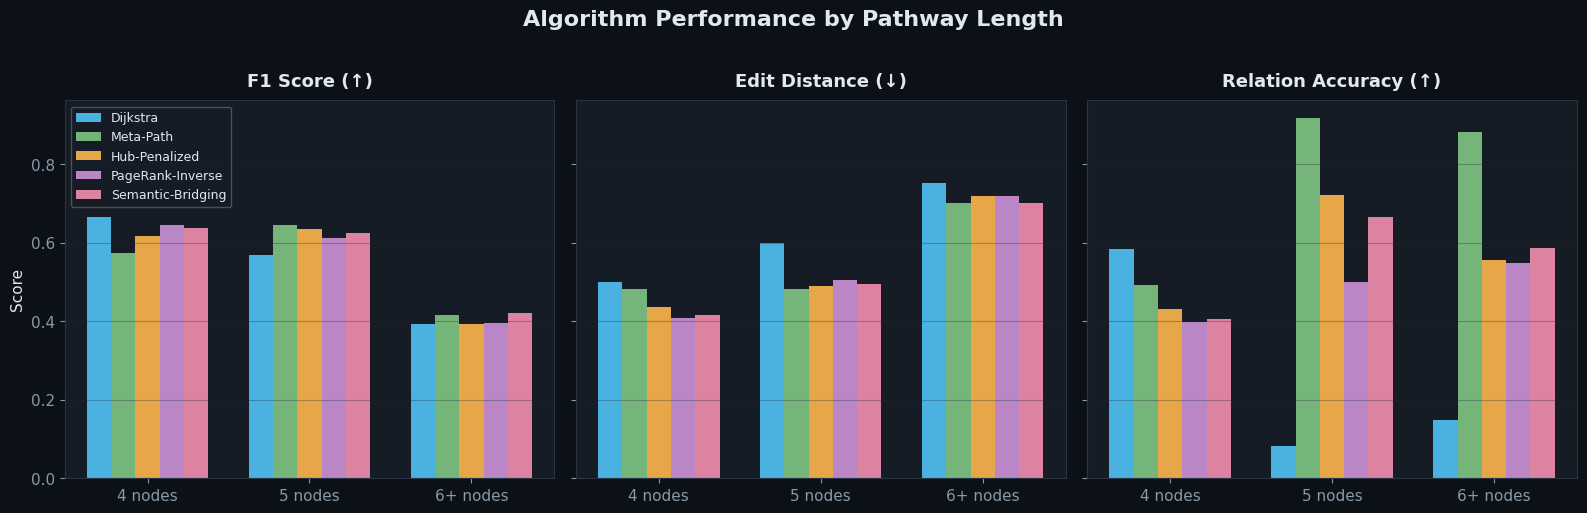

PERFORMANCE BY PATHWAY LENGTH

f1_score:
algorithm      Dijkstra  Hub-Penalized  Meta-Path  PageRank-Inverse  Semantic-Bridging
length_bucket                                                                         
4 nodes           0.667          0.616      0.573             0.646              0.638
5 nodes           0.569          0.634      0.646             0.611              0.625
6+ nodes          0.393          0.394      0.415             0.395              0.421

edit_distance:
algorithm      Dijkstra  Hub-Penalized  Meta-Path  PageRank-Inverse  Semantic-Bridging
length_bucket                                                                         
4 nodes           0.500          0.437      0.482             0.409              0.417
5 nodes           0.600          0.489      0.483             0.506              0.494
6+ nodes          0.752          0.720      0.702             0.719              0.700

relation_accuracy:
algorithm      Dijkstra  Hub-Penalized  Meta-Path  Pa

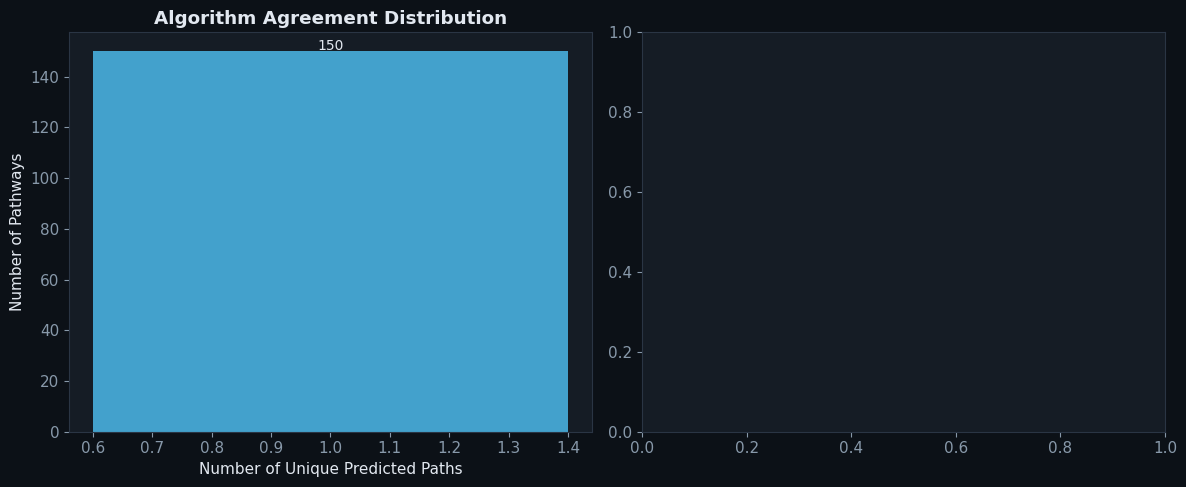


METRIC CORRELATION ANALYSIS


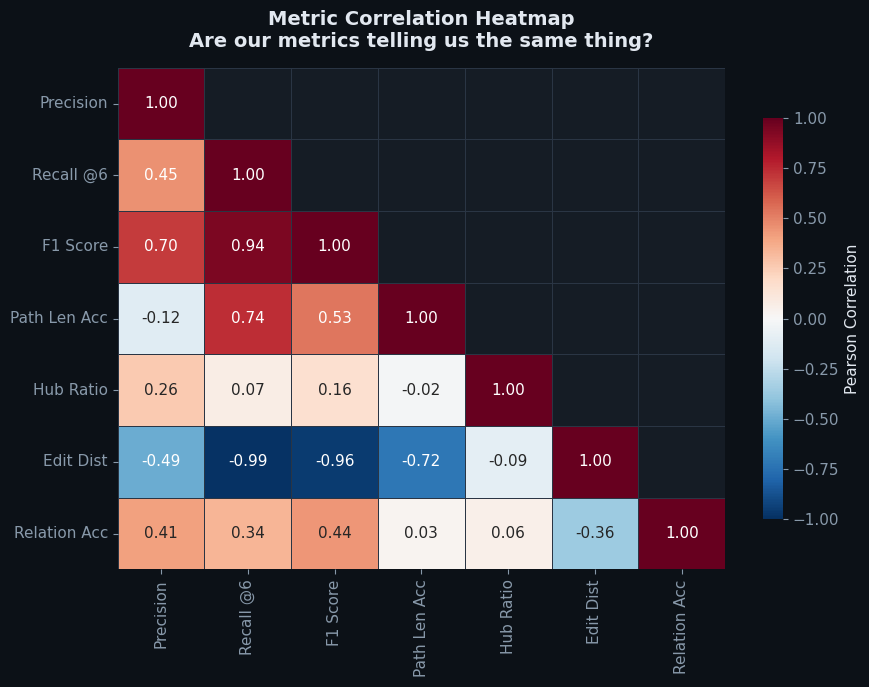


Notable correlations:
  Precision ↔ F1 Score: r=0.698 (positively correlated)
  Recall @6 ↔ F1 Score: r=0.944 (positively correlated)
  Recall @6 ↔ Path Len Acc: r=0.740 (positively correlated)
  Recall @6 ↔ Edit Dist: r=-0.991 (negatively correlated)
  F1 Score ↔ Path Len Acc: r=0.534 (positively correlated)
  F1 Score ↔ Edit Dist: r=-0.960 (negatively correlated)
  Path Len Acc ↔ Edit Dist: r=-0.724 (negatively correlated)

MOST FREQUENT INTERMEDIATE NODES IN PREDICTED PATHS

Top 15 most common intermediate nodes across ALL predictions:
------------------------------------------------------------

Top 5 intermediates PER ALGORITHM:

  Dijkstra:

  Hub-Penalized:

  Meta-Path:

  PageRank-Inverse:

  Semantic-Bridging:


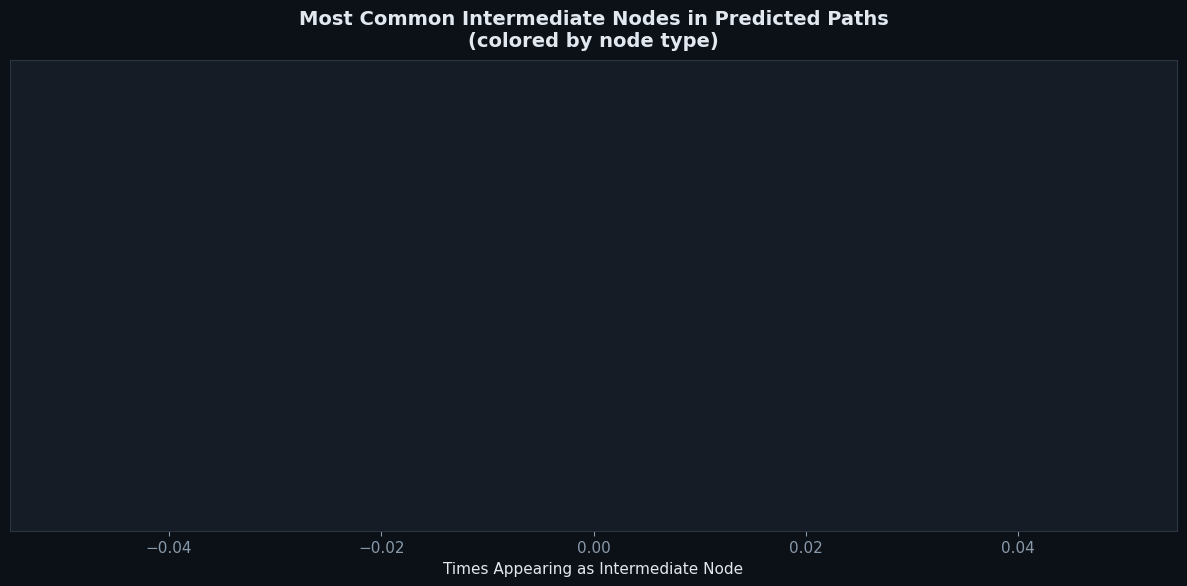


POSTER-READY SUMMARY STATS

Dataset: 150 pathways evaluated across 5 algorithms
Pathway lengths: min=4, max=11, mean=5.8, median=5

Overall rankings (by F1 score):
  1. Semantic-Bridging: 0.5569
  2. PageRank-Inverse: 0.5472
  3. Dijkstra: 0.5448
  4. Hub-Penalized: 0.5403
  5. Meta-Path: 0.5338

Overall rankings (by edit distance, lower = better):
  1. Semantic-Bridging: 0.5374
  2. PageRank-Inverse: 0.5437
  3. Hub-Penalized: 0.5513
  4. Meta-Path: 0.5612
  5. Dijkstra: 0.6146


In [23]:
# ============================================================
# ANALYSIS 1: Performance by Pathway Length
# ============================================================
# 
# Drop this cell (and the ones below) at the bottom of your
# notebook AFTER running the evaluation.  The only variables
# it needs are:
#   results          – the per-pathway DataFrame from run_evaluation()
#   summary          – the per-algorithm summary from run_evaluation()
#   ground_truth_nodes – your filtered ground truth nodes DataFrame
#
# All plots save to PNG so you can drag them onto your poster.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns

# --- Poster-friendly style ---
matplotlib.rcParams.update({
    'figure.facecolor': '#0c1117',
    'axes.facecolor': '#151c25',
    'axes.edgecolor': '#2a3544',
    'axes.labelcolor': '#e2e8f0',
    'text.color': '#e2e8f0',
    'xtick.color': '#8899aa',
    'ytick.color': '#8899aa',
    'grid.color': '#1a2332',
    'font.family': 'sans-serif',
    'font.size': 11,
})

ALGO_COLORS = {
    'Dijkstra': '#4fc3f7',
    'Meta-Path': '#81c784',
    'Hub-Penalized': '#ffb74d',
    'PageRank-Inverse': '#ce93d8',
    'Semantic-Bridging': '#f48fb1',
}

# Map pathway_id → ground truth length
gt_lengths = ground_truth_nodes.groupby('pathway_id')['node_index'].count()
gt_lengths.name = 'gt_length'

# Merge into results
analysis_df = results.merge(gt_lengths, on='pathway_id', how='left')

# Create length buckets
def length_bucket(n):
    if n == 4:
        return '4 nodes'
    elif n == 5:
        return '5 nodes'
    else:
        return '6+ nodes'

analysis_df['length_bucket'] = analysis_df['gt_length'].apply(length_bucket)

# --- Plot: F1 by pathway length ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
metrics_to_plot = ['f1_score', 'edit_distance', 'relation_accuracy']
titles = ['F1 Score (↑)', 'Edit Distance (↓)', 'Relation Accuracy (↑)']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    pivot = analysis_df.groupby(['length_bucket', 'algorithm'])[metric].mean().unstack('algorithm')
    # Reorder buckets
    bucket_order = [b for b in ['4 nodes', '5 nodes', '6+ nodes'] if b in pivot.index]
    pivot = pivot.loc[bucket_order]
    
    bar_width = 0.15
    x = np.arange(len(bucket_order))
    
    for i, algo in enumerate(ALGO_COLORS.keys()):
        if algo in pivot.columns:
            vals = pivot[algo].values
            ax.bar(x + i * bar_width, vals, bar_width, 
                   color=ALGO_COLORS[algo], label=algo, alpha=0.9)
    
    ax.set_xticks(x + bar_width * 2)
    ax.set_xticklabels(bucket_order)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Score')
axes[0].legend(fontsize=9, loc='upper left', framealpha=0.3)

plt.suptitle('Algorithm Performance by Pathway Length', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('analysis_performance_by_length.png', dpi=200, bbox_inches='tight',
            facecolor='#0c1117', edgecolor='none')
plt.show()

# Print the numbers
print("=" * 70)
print("PERFORMANCE BY PATHWAY LENGTH")
print("=" * 70)
for metric in metrics_to_plot:
    print(f"\n{metric}:")
    pivot = analysis_df.groupby(['length_bucket', 'algorithm'])[metric].mean().unstack('algorithm').round(3)
    bucket_order = [b for b in ['4 nodes', '5 nodes', '6+ nodes'] if b in pivot.index]
    print(pivot.loc[bucket_order].to_string())


# ============================================================
# ANALYSIS 2: Algorithm Agreement
# ============================================================

print("\n" + "=" * 70)
print("ALGORITHM AGREEMENT ANALYSIS")
print("=" * 70)

algos = results['algorithm'].unique().tolist()

# For each pathway, get each algorithm's predicted path
agreement_records = []

for pathway_id in results['pathway_id'].unique():
    pw = results[results['pathway_id'] == pathway_id]
    
    # Get predicted node lists per algorithm
    paths = {}
    for _, row in pw.iterrows():
        algo = row['algorithm']
        pred_nodes = str(row.get('predicted_node_indices', ''))
        paths[algo] = pred_nodes
    
    # Count how many unique paths were found
    unique_paths = len(set(paths.values()))
    n_algos = len(paths)
    
    # Check if all agree
    all_agree = unique_paths == 1
    
    # Get the best edit distance for this pathway
    best_edit = pw['edit_distance'].min()
    avg_edit = pw['edit_distance'].mean()
    
    agreement_records.append({
        'pathway_id': pathway_id,
        'n_algorithms': n_algos,
        'unique_paths': unique_paths,
        'all_agree': all_agree,
        'best_edit_distance': best_edit,
        'avg_edit_distance': avg_edit,
        'gt_length': pw['gt_length'].iloc[0] if 'gt_length' in pw.columns else None
    })

agreement_df = pd.DataFrame(agreement_records)

total = len(agreement_df)
full_agree = agreement_df['all_agree'].sum()
print(f"\nPathways where ALL algorithms agree: {full_agree}/{total} ({100*full_agree/total:.1f}%)")
print(f"Pathways with disagreement: {total - full_agree}/{total}")

# When they agree, how good are they?
if full_agree > 0:
    agree_edit = agreement_df[agreement_df['all_agree']]['best_edit_distance'].mean()
    disagree_edit = agreement_df[~agreement_df['all_agree']]['best_edit_distance'].mean()
    print(f"\nAvg edit distance when all agree:    {agree_edit:.3f}")
    print(f"Avg edit distance when they disagree: {disagree_edit:.3f}")

# Distribution of unique paths
print("\nDistribution of unique predicted paths per pathway:")
for n in sorted(agreement_df['unique_paths'].unique()):
    count = (agreement_df['unique_paths'] == n).sum()
    print(f"  {n} unique paths: {count} pathways ({100*count/total:.1f}%)")

# Which algorithm is most often "the right one" when others disagree?
print("\nWhen algorithms disagree, which one has the lowest edit distance?")
disagree_pathways = agreement_df[~agreement_df['all_agree']]['pathway_id'].tolist()

winner_counts = {}
for pathway_id in disagree_pathways:
    pw = results[results['pathway_id'] == pathway_id]
    best_row = pw.loc[pw['edit_distance'].idxmin()]
    winner = best_row['algorithm']
    winner_counts[winner] = winner_counts.get(winner, 0) + 1

for algo, count in sorted(winner_counts.items(), key=lambda x: -x[1]):
    print(f"  {algo}: best in {count}/{len(disagree_pathways)} disagreements ({100*count/len(disagree_pathways):.1f}%)")


# --- Agreement visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: distribution of unique paths
ax = axes[0]
unique_counts = agreement_df['unique_paths'].value_counts().sort_index()
bars = ax.bar(unique_counts.index, unique_counts.values, color='#4fc3f7', alpha=0.8)
ax.set_xlabel('Number of Unique Predicted Paths')
ax.set_ylabel('Number of Pathways')
ax.set_title('Algorithm Agreement Distribution', fontweight='bold')
for bar, val in zip(bars, unique_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            str(val), ha='center', fontsize=10, color='#e2e8f0')

# Right: winner when disagreeing
ax = axes[1]
if winner_counts:
    algos_sorted = sorted(winner_counts.keys(), key=lambda a: winner_counts[a], reverse=True)
    vals = [winner_counts[a] for a in algos_sorted]
    colors = [ALGO_COLORS.get(a, '#888') for a in algos_sorted]
    bars = ax.barh(range(len(algos_sorted)), vals, color=colors, alpha=0.85)
    ax.set_yticks(range(len(algos_sorted)))
    ax.set_yticklabels(algos_sorted)
    ax.set_xlabel('Times Best When Others Disagree')
    ax.set_title('Best Algorithm in Disagreements', fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('analysis_algorithm_agreement.png', dpi=200, bbox_inches='tight',
            facecolor='#0c1117', edgecolor='none')
plt.show()


# ============================================================
# ANALYSIS 3: Metric Correlation Heatmap
# ============================================================

print("\n" + "=" * 70)
print("METRIC CORRELATION ANALYSIS")
print("=" * 70)

# Pivot: for each pathway, get each algorithm's metrics
# Then compute correlation across all (pathway, algorithm) pairs
metric_cols = ['precision', 'recall_at_6_hops', 'f1_score', 'path_length_accuracy',
               'hub_node_ratio', 'edit_distance', 'relation_accuracy']

# Only use columns that exist in results
available_metrics = [m for m in metric_cols if m in results.columns]

corr_matrix = results[available_metrics].corr()

# Pretty names for display
pretty_names = {
    'precision': 'Precision',
    'recall_at_6_hops': 'Recall @6',
    'f1_score': 'F1 Score',
    'path_length_accuracy': 'Path Len Acc',
    'hub_node_ratio': 'Hub Ratio',
    'edit_distance': 'Edit Dist',
    'relation_accuracy': 'Relation Acc',
}

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

display_labels = [pretty_names.get(m, m) for m in available_metrics]

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            xticklabels=display_labels, yticklabels=display_labels,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#2a3544',
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
            ax=ax)

ax.set_title('Metric Correlation Heatmap\nAre our metrics telling us the same thing?',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('analysis_metric_correlation.png', dpi=200, bbox_inches='tight',
            facecolor='#0c1117', edgecolor='none')
plt.show()

# Flag interesting correlations
print("\nNotable correlations:")
for i in range(len(available_metrics)):
    for j in range(i+1, len(available_metrics)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            direction = "positively" if r > 0 else "negatively"
            print(f"  {pretty_names.get(available_metrics[i], available_metrics[i])} ↔ "
                  f"{pretty_names.get(available_metrics[j], available_metrics[j])}: "
                  f"r={r:.3f} ({direction} correlated)")


# ============================================================
# ANALYSIS 4: Top Hub Nodes Across Predictions
# ============================================================

print("\n" + "=" * 70)
print("MOST FREQUENT INTERMEDIATE NODES IN PREDICTED PATHS")
print("=" * 70)

# Collect all intermediate nodes (exclude source and target) from predictions
from collections import Counter

intermediate_counts = Counter()
intermediate_by_algo = {algo: Counter() for algo in results['algorithm'].unique()}

for _, row in results.iterrows():
    pred_indices = str(row.get('predicted_node_indices', ''))
    if not pred_indices or pred_indices == 'nan':
        continue
    
    nodes = pred_indices.split(',')
    # Intermediate = everything except first and last
    if len(nodes) > 2:
        intermediates = nodes[1:-1]
        for node_idx in intermediates:
            node_idx = node_idx.strip()
            if node_idx:
                intermediate_counts[node_idx] += 1
                intermediate_by_algo[row['algorithm']][node_idx] += 1

# Get node names from the graph (G should still be in scope)
print(f"\nTop 15 most common intermediate nodes across ALL predictions:")
print("-" * 60)
for node_idx, count in intermediate_counts.most_common(15):
    try:
        node_int = int(node_idx)
        name = G.nodes[node_int].get('node_name', node_idx)
        ntype = G.nodes[node_int].get('node_type', '?')
        degree = G.degree(node_int)
    except (ValueError, KeyError):
        name, ntype, degree = node_idx, '?', '?'
    
    print(f"  {name:40s} [{ntype:15s}] degree={str(degree):>6s}  appeared {count}x")

# Per algorithm
print(f"\nTop 5 intermediates PER ALGORITHM:")
for algo in sorted(intermediate_by_algo.keys()):
    print(f"\n  {algo}:")
    for node_idx, count in intermediate_by_algo[algo].most_common(5):
        try:
            node_int = int(node_idx)
            name = G.nodes[node_int].get('node_name', node_idx)
            ntype = G.nodes[node_int].get('node_type', '?')
        except (ValueError, KeyError):
            name, ntype = node_idx, '?'
        print(f"    {name:40s} [{ntype:15s}]  {count}x")

# Visualize top intermediates
fig, ax = plt.subplots(figsize=(12, 6))
top_n = 12
top_nodes = intermediate_counts.most_common(top_n)
node_labels = []
node_vals = []
node_colors = []

type_colors = {
    'gene/protein': '#81c784',
    'disease': '#f48fb1',
    'drug': '#4fc3f7',
    'biological_process': '#ffb74d',
    'pathway': '#ce93d8',
}

for node_idx, count in top_nodes:
    try:
        node_int = int(node_idx)
        name = G.nodes[node_int].get('node_name', node_idx)
        ntype = G.nodes[node_int].get('node_type', '?')
    except (ValueError, KeyError):
        name, ntype = node_idx, '?'
    
    # Truncate long names
    if len(name) > 25:
        name = name[:22] + '...'
    node_labels.append(name)
    node_vals.append(count)
    node_colors.append(type_colors.get(ntype, '#888888'))

bars = ax.barh(range(len(node_labels)), node_vals, color=node_colors, alpha=0.85)
ax.set_yticks(range(len(node_labels)))
ax.set_yticklabels(node_labels, fontsize=10)
ax.set_xlabel('Times Appearing as Intermediate Node')
ax.set_title('Most Common Intermediate Nodes in Predicted Paths\n(colored by node type)',
             fontsize=14, fontweight='bold', pad=10)
ax.invert_yaxis()

# Legend for node types
from matplotlib.patches import Patch
legend_items = [Patch(facecolor=c, alpha=0.85, label=t) 
                for t, c in type_colors.items() if any(True for _, _ in [])]
# Build legend from actually used types
used_types = set()
for node_idx, _ in top_nodes:
    try:
        ntype = G.nodes[int(node_idx)].get('node_type', '?')
        used_types.add(ntype)
    except (ValueError, KeyError):
        pass
legend_items = [Patch(facecolor=type_colors.get(t, '#888'), alpha=0.85, label=t) 
                for t in used_types if t in type_colors]
if legend_items:
    ax.legend(handles=legend_items, loc='lower right', fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig('analysis_hub_nodes.png', dpi=200, bbox_inches='tight',
            facecolor='#0c1117', edgecolor='none')
plt.show()


# ============================================================
# ANALYSIS 5: Quick Summary for Poster
# ============================================================

print("\n" + "=" * 70)
print("POSTER-READY SUMMARY STATS")
print("=" * 70)

n_pathways = results['pathway_id'].nunique()
n_algos = results['algorithm'].nunique()

print(f"\nDataset: {n_pathways} pathways evaluated across {n_algos} algorithms")

if 'gt_length' in analysis_df.columns:
    length_dist = analysis_df.drop_duplicates('pathway_id')['gt_length'].describe()
    print(f"Pathway lengths: min={length_dist['min']:.0f}, max={length_dist['max']:.0f}, "
          f"mean={length_dist['mean']:.1f}, median={length_dist['50%']:.0f}")

print(f"\nOverall rankings (by F1 score):")
f1_ranking = results.groupby('algorithm')['f1_score'].mean().sort_values(ascending=False)
for rank, (algo, score) in enumerate(f1_ranking.items(), 1):
    print(f"  {rank}. {algo}: {score:.4f}")

print(f"\nOverall rankings (by edit distance, lower = better):")
ed_ranking = results.groupby('algorithm')['edit_distance'].mean().sort_values(ascending=True)
for rank, (algo, score) in enumerate(ed_ranking.items(), 1):
    print(f"  {rank}. {algo}: {score:.4f}")

In [26]:
# ============================================================
# BIDIRECTIONAL SEARCH - FAST VERSION
# ============================================================
# Searches from drug AND disease simultaneously, meets in middle.
# Should run in 2-5 minutes — it's just two bounded Dijkstras.
# Needs: G, ground_truth_nodes, results, allowed_transition
# ============================================================

import heapq
import numpy as np
import pandas as pd
import time
import sys
from difflib import SequenceMatcher
from scipy import stats


class BidirectionalFast:
    def __init__(self, graph, max_depth=8, max_explore=50000):
        self.graph = graph
        self.max_depth = max_depth
        self.max_explore = max_explore

    def find_path(self, source, target):
        if source == target:
            return [source], [], 0.0

        # Forward state
        dist_f = {source: 0.0}
        parent_f = {source: None}
        pq_f = [(0.0, source)]
        visited_f = set()

        # Backward state
        dist_b = {target: 0.0}
        parent_b = {target: None}
        pq_b = [(0.0, target)]
        visited_b = set()

        best_cost = float('inf')
        meeting_node = None
        explored = 0

        while pq_f or pq_b:
            explored += 1
            if explored > self.max_explore:
                break

            # Forward step
            if pq_f:
                cost_f, u_f = heapq.heappop(pq_f)
                if cost_f > self.max_depth:
                    pq_f = []
                elif cost_f == dist_f.get(u_f, float('inf')) and cost_f <= best_cost:
                    visited_f.add(u_f)
                    for v in self.graph.successors(u_f):
                        if not allowed_transition(self.graph, source, u_f, v):
                            continue
                        new_cost = cost_f + 1.0
                        if new_cost < dist_f.get(v, float('inf')):
                            dist_f[v] = new_cost
                            parent_f[v] = u_f
                            heapq.heappush(pq_f, (new_cost, v))
                            if v in dist_b:
                                total = new_cost + dist_b[v]
                                if total < best_cost:
                                    best_cost = total
                                    meeting_node = v

            # Backward step
            if pq_b:
                cost_b, u_b = heapq.heappop(pq_b)
                if cost_b > self.max_depth:
                    pq_b = []
                elif cost_b == dist_b.get(u_b, float('inf')) and cost_b <= best_cost:
                    visited_b.add(u_b)
                    for v in self.graph.predecessors(u_b):
                        new_cost = cost_b + 1.0
                        if new_cost < dist_b.get(v, float('inf')):
                            dist_b[v] = new_cost
                            parent_b[v] = u_b
                            heapq.heappush(pq_b, (new_cost, v))
                            if v in dist_f:
                                total = dist_f[v] + new_cost
                                if total < best_cost:
                                    best_cost = total
                                    meeting_node = v

            # Early termination
            min_f = pq_f[0][0] if pq_f else float('inf')
            min_b = pq_b[0][0] if pq_b else float('inf')
            if min_f + min_b >= best_cost:
                break

        if meeting_node is None:
            return [], [], float('inf')

        # Reconstruct forward half: source → meeting
        fwd = []
        cur = meeting_node
        while cur is not None:
            fwd.append(cur)
            cur = parent_f.get(cur)
        fwd.reverse()

        # Reconstruct backward half: meeting → target
        bwd = []
        cur = parent_b.get(meeting_node)
        while cur is not None:
            bwd.append(cur)
            cur = parent_b.get(cur)

        full_path = fwd + bwd

        # Validate edges exist and constraints hold
        valid = [full_path[0]]
        for i in range(len(full_path) - 1):
            u, v = full_path[i], full_path[i + 1]
            if self.graph.has_edge(u, v) and allowed_transition(self.graph, source, u, v):
                valid.append(v)
            else:
                # Path broken — fall back to forward-only Dijkstra
                return self._fallback(source, target)

        if valid[-1] != target:
            return self._fallback(source, target)

        relations = []
        for i in range(len(valid) - 1):
            ed = self.graph.get_edge_data(valid[i], valid[i + 1]) or {}
            relations.append(ed.get("relation", "unknown"))

        return valid, relations, float(len(valid) - 1)

    def _fallback(self, source, target):
        dist = {source: 0.0}
        parent = {source: None}
        pq = [(0.0, source)]
        explored = 0

        while pq:
            cost, u = heapq.heappop(pq)
            if cost != dist.get(u, float('inf')):
                continue
            explored += 1
            if explored > self.max_explore or cost > self.max_depth:
                break
            if u == target:
                break
            for v in self.graph.successors(u):
                if not allowed_transition(self.graph, source, u, v):
                    continue
                nc = cost + 1.0
                if nc < dist.get(v, float('inf')):
                    dist[v] = nc
                    parent[v] = u
                    heapq.heappush(pq, (nc, v))

        if target not in dist:
            return [], [], float('inf')

        path = []
        cur = target
        while cur is not None:
            path.append(cur)
            cur = parent[cur]
        path.reverse()

        relations = []
        for i in range(len(path) - 1):
            ed = self.graph.get_edge_data(path[i], path[i + 1]) or {}
            relations.append(ed.get("relation", "unknown"))
        return path, relations, dist[target]


# ============================================================
# RUN
# ============================================================

print("Initializing Bidirectional Search...")
bidir = BidirectionalFast(G, max_depth=8, max_explore=50000)

pathway_endpoints = ground_truth_nodes.groupby('pathway_id').agg(
    source_index=('node_index', 'first'),
    target_index=('node_index', 'last')
).reset_index()

total = len(pathway_endpoints)
print(f"Running on {total} pathways...\n")

records = []
successes = 0
fallbacks = 0
t0 = time.time()

def progress_bar(current, total, elapsed, successes, bar_len=40):
    frac = current / total
    filled = int(bar_len * frac)
    bar = '█' * filled + '░' * (bar_len - filled)
    pct = frac * 100
    rate = current / elapsed if elapsed > 0 else 0
    eta = (total - current) / rate if rate > 0 else 0
    mins, secs = divmod(int(eta), 60)
    e_mins, e_secs = divmod(int(elapsed), 60)
    sys.stdout.write(
        f'\r  {bar} {pct:5.1f}% | {current}/{total} | '
        f'{successes} found | {e_mins}:{e_secs:02d} elapsed | ETA {mins}:{secs:02d}  '
    )
    sys.stdout.flush()

for idx, row in pathway_endpoints.iterrows():
    pathway_id = row['pathway_id']
    source = row['source_index']
    target = row['target_index']

    try:
        path_nodes, relations, cost = bidir.find_path(source, target)

        if path_nodes and path_nodes[-1] == target:
            successes += 1
            gt = ground_truth_nodes[ground_truth_nodes['pathway_id'] == pathway_id]
            gt_node_set = set(gt['node_index'].tolist())
            pred_node_set = set(path_nodes)

            tp = len(gt_node_set & pred_node_set)
            prec = tp / len(pred_node_set) if pred_node_set else 0
            rec = tp / len(gt_node_set) if gt_node_set else 0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

            gt_list = gt.sort_values('step_order')['node_index'].tolist() if 'step_order' in gt.columns else gt['node_index'].tolist()
            sm = SequenceMatcher(None, gt_list, path_nodes)
            edit_dist = 1 - sm.ratio()

            records.append({
                'pathway_id': pathway_id,
                'algorithm': 'Bidirectional',
                'f1_score': f1,
                'precision': prec,
                'recall': rec,
                'edit_distance': edit_dist,
                'pred_length': len(path_nodes),
                'gt_length': len(gt_node_set),
                'predicted_node_indices': ','.join(str(n) for n in path_nodes),
            })
    except Exception:
        pass

    elapsed = time.time() - t0
    progress_bar(idx + 1, total, elapsed, successes)

total_time = time.time() - t0
print(f"\n\n  Done! {total_time:.1f}s ({successes}/{total} paths found)")

bidir_results = pd.DataFrame(records)

# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)

bi_f1 = bidir_results['f1_score'].mean()
bi_ed = bidir_results['edit_distance'].mean()

print(f"\nBidirectional:   F1 = {bi_f1:.4f}  |  Edit Dist = {bi_ed:.4f}")

print(f"\nAll algorithms:")
orig = results.groupby('algorithm')[['f1_score', 'edit_distance']].mean().sort_values('f1_score', ascending=False)
for algo, row in orig.iterrows():
    print(f"  {algo:25s}: F1 = {row['f1_score']:.4f}  |  Edit Dist = {row['edit_distance']:.4f}")

# Include K-Shortest if it exists
if 'new_results' in dir() and len(new_results) > 0:
    ksb_f1 = new_results['f1_score'].mean()
    ksb_ed = new_results['edit_distance'].mean()
    print(f"  {'K-Shortest-Bio':25s}: F1 = {ksb_f1:.4f}  |  Edit Dist = {ksb_ed:.4f}")

# Full ranking by F1
all_f1 = results.groupby('algorithm')['f1_score'].mean()
all_f1['Bidirectional'] = bi_f1
if 'new_results' in dir() and len(new_results) > 0:
    all_f1['K-Shortest-Bio'] = new_results['f1_score'].mean()
all_f1 = all_f1.sort_values(ascending=False)

print(f"\nRANKING BY F1:")
for rank, (algo, score) in enumerate(all_f1.items(), 1):
    marker = " ← NEW" if algo in ['Bidirectional', 'K-Shortest-Bio'] else ""
    print(f"  {rank}. {algo:25s}: F1 = {score:.4f}{marker}")

# Full ranking by edit distance
all_ed = results.groupby('algorithm')['edit_distance'].mean()
all_ed['Bidirectional'] = bi_ed
if 'new_results' in dir() and len(new_results) > 0:
    all_ed['K-Shortest-Bio'] = new_results['edit_distance'].mean()
all_ed = all_ed.sort_values(ascending=True)

print(f"\nRANKING BY EDIT DISTANCE (lower = better):")
for rank, (algo, score) in enumerate(all_ed.items(), 1):
    marker = " ← NEW" if algo in ['Bidirectional', 'K-Shortest-Bio'] else ""
    print(f"  {rank}. {algo:25s}: ED = {score:.4f}{marker}")

# Significance tests
print(f"\n--- Significance (F1) ---")
for compare in ['Semantic-Bridging', 'Dijkstra']:
    if compare not in results['algorithm'].values:
        continue
    orig_scores = results[results['algorithm'] == compare][['pathway_id', 'f1_score']].rename(columns={'f1_score': 'f1_orig'})
    bi_scores = bidir_results[['pathway_id', 'f1_score']].rename(columns={'f1_score': 'f1_new'})
    paired = orig_scores.merge(bi_scores, on='pathway_id')
    diff = paired['f1_new'] - paired['f1_orig']
    nonzero = diff[diff != 0]
    if len(nonzero) >= 5:
        stat, p = stats.wilcoxon(nonzero)
        d = diff.mean() / diff.std() if diff.std() > 0 else 0
        sig = "✓ SIG" if p < 0.05 else "  n.s."
        print(f"  [{sig}] Bidirectional vs {compare:20s}: Δ={diff.mean():+.4f}  p={p:.6f}  d={d:+.3f}")

print(f"\n--- Significance (Edit Distance) ---")
for compare in ['Semantic-Bridging', 'Dijkstra', 'PageRank-Inverse']:
    if compare not in results['algorithm'].values:
        continue
    orig_ed = results[results['algorithm'] == compare][['pathway_id', 'edit_distance']].rename(columns={'edit_distance': 'ed_orig'})
    bi_ed_scores = bidir_results[['pathway_id', 'edit_distance']].rename(columns={'edit_distance': 'ed_new'})
    paired = orig_ed.merge(bi_ed_scores, on='pathway_id')
    diff = paired['ed_new'] - paired['ed_orig']
    nonzero = diff[diff != 0]
    if len(nonzero) >= 5:
        stat, p = stats.wilcoxon(nonzero)
        d = diff.mean() / diff.std() if diff.std() > 0 else 0
        sig = "✓ SIG" if p < 0.05 else "  n.s."
        print(f"  [{sig}] Bidirectional vs {compare:20s}: Δ={diff.mean():+.4f}  p={p:.6f}  d={d:+.3f}")

Initializing Bidirectional Search...
Running on 150 pathways...

  ████████████████████████████████████████ 100.0% | 150/150 | 150 found | 6:50 elapsed | ETA 0:00  

  Done! 410.6s (150/150 paths found)

RESULTS

Bidirectional:   F1 = 0.5709  |  Edit Dist = 0.4291

All algorithms:
  Semantic-Bridging        : F1 = 0.5569  |  Edit Dist = 0.5374
  PageRank-Inverse         : F1 = 0.5472  |  Edit Dist = 0.5437
  Dijkstra                 : F1 = 0.5448  |  Edit Dist = 0.6146
  Hub-Penalized            : F1 = 0.5403  |  Edit Dist = 0.5513
  Meta-Path                : F1 = 0.5338  |  Edit Dist = 0.5612

RANKING BY F1:
  1. Bidirectional            : F1 = 0.5709 ← NEW
  2. Semantic-Bridging        : F1 = 0.5569
  3. PageRank-Inverse         : F1 = 0.5472
  4. Dijkstra                 : F1 = 0.5448
  5. Hub-Penalized            : F1 = 0.5403
  6. Meta-Path                : F1 = 0.5338

RANKING BY EDIT DISTANCE (lower = better):
  1. Bidirectional            : ED = 0.4291 ← NEW
  2. Semantic-Brid

In [27]:
# ============================================================
# BIDIRECTIONAL K-SHORTEST WITH BIOLOGICAL RE-RANKING
# ============================================================
# Combines the two strategies that actually worked:
#   - Bidirectional search (best F1 and edit distance)
#   - Biological plausibility scoring (from K-Shortest)
#
# How: find k=4 shortest paths using bidirectional search,
# then pick the most biologically plausible one.
#
# Should run in ~10-15 minutes (similar to bidirectional alone).
# Needs: G, ground_truth_nodes, results, allowed_transition
# ============================================================

import heapq
import numpy as np
import pandas as pd
import time
import sys
from difflib import SequenceMatcher
from scipy import stats


class BidirectionalKShortestBio:
    def __init__(self, graph, k=4, max_depth=8, max_explore=50000):
        self.graph = graph
        self.k = k
        self.max_depth = max_depth
        self.max_explore = max_explore
        self.degrees = dict(graph.degree())
        degree_vals = list(self.degrees.values())
        self.degree_p90 = np.percentile(degree_vals, 90)
        self.degree_p99 = np.percentile(degree_vals, 99)

    def _bidir_shortest(self, source, target, excluded_edges=None, excluded_nodes=None):
        """Single bidirectional shortest path with exclusions."""
        if excluded_edges is None:
            excluded_edges = set()
        if excluded_nodes is None:
            excluded_nodes = set()

        dist_f = {source: 0.0}
        parent_f = {source: None}
        pq_f = [(0.0, source)]

        dist_b = {target: 0.0}
        parent_b = {target: None}
        pq_b = [(0.0, target)]

        best_cost = float('inf')
        meeting = None
        explored = 0

        while pq_f or pq_b:
            explored += 1
            if explored > self.max_explore:
                break

            if pq_f:
                cf, uf = heapq.heappop(pq_f)
                if cf > self.max_depth:
                    pq_f = []
                elif cf == dist_f.get(uf, float('inf')) and cf <= best_cost:
                    for v in self.graph.successors(uf):
                        if v in excluded_nodes or (uf, v) in excluded_edges:
                            continue
                        if not allowed_transition(self.graph, source, uf, v):
                            continue
                        nc = cf + 1.0
                        if nc < dist_f.get(v, float('inf')):
                            dist_f[v] = nc
                            parent_f[v] = uf
                            heapq.heappush(pq_f, (nc, v))
                            if v in dist_b and nc + dist_b[v] < best_cost:
                                best_cost = nc + dist_b[v]
                                meeting = v

            if pq_b:
                cb, ub = heapq.heappop(pq_b)
                if cb > self.max_depth:
                    pq_b = []
                elif cb == dist_b.get(ub, float('inf')) and cb <= best_cost:
                    for v in self.graph.predecessors(ub):
                        if v in excluded_nodes or (v, ub) in excluded_edges:
                            continue
                        nc = cb + 1.0
                        if nc < dist_b.get(v, float('inf')):
                            dist_b[v] = nc
                            parent_b[v] = ub
                            heapq.heappush(pq_b, (nc, v))
                            if v in dist_f and dist_f[v] + nc < best_cost:
                                best_cost = dist_f[v] + nc
                                meeting = v

            min_f = pq_f[0][0] if pq_f else float('inf')
            min_b = pq_b[0][0] if pq_b else float('inf')
            if min_f + min_b >= best_cost:
                break

        if meeting is None:
            return None, float('inf')

        # Reconstruct
        fwd = []
        cur = meeting
        while cur is not None:
            fwd.append(cur)
            cur = parent_f.get(cur)
        fwd.reverse()

        bwd = []
        cur = parent_b.get(meeting)
        while cur is not None:
            bwd.append(cur)
            cur = parent_b.get(cur)

        path = fwd + bwd

        # Validate
        for i in range(len(path) - 1):
            if not self.graph.has_edge(path[i], path[i + 1]):
                return None, float('inf')
            if not allowed_transition(self.graph, source, path[i], path[i + 1]):
                return None, float('inf')

        if path[-1] != target:
            return None, float('inf')

        return path, float(len(path) - 1)

    def _fwd_shortest(self, source, target, excluded_edges=None, excluded_nodes=None):
        """Forward-only fallback."""
        if excluded_edges is None:
            excluded_edges = set()
        if excluded_nodes is None:
            excluded_nodes = set()

        dist = {source: 0.0}
        parent = {source: None}
        pq = [(0.0, source)]

        while pq:
            cost, u = heapq.heappop(pq)
            if cost != dist.get(u, float('inf')):
                continue
            if cost > self.max_depth:
                break
            if u == target:
                break
            for v in self.graph.successors(u):
                if v in excluded_nodes or (u, v) in excluded_edges:
                    continue
                if not allowed_transition(self.graph, source, u, v):
                    continue
                nc = cost + 1.0
                if nc < dist.get(v, float('inf')):
                    dist[v] = nc
                    parent[v] = u
                    heapq.heappush(pq, (nc, v))

        if target not in dist:
            return None, float('inf')

        path = []
        cur = target
        while cur is not None:
            path.append(cur)
            cur = parent[cur]
        path.reverse()
        return path, dist[target]

    def _find_k_paths(self, source, target):
        """Find k diverse paths using Yen's with bidirectional base search."""
        # Try bidirectional first, fall back to forward
        first_path, first_cost = self._bidir_shortest(source, target)
        if first_path is None:
            first_path, first_cost = self._fwd_shortest(source, target)
        if first_path is None:
            return []

        A = [(first_path, first_cost)]
        B = []
        seen = {tuple(first_path)}
        counter = 0

        for _ in range(1, self.k):
            prev_path = A[-1][0]
            max_spur = min(len(prev_path) - 1, 4)

            for i in range(max_spur):
                spur_node = prev_path[i]
                root_path = prev_path[:i + 1]

                excl_edges = set()
                for (p, _) in A:
                    if len(p) > i and p[:i + 1] == root_path and i + 1 < len(p):
                        excl_edges.add((p[i], p[i + 1]))

                excl_nodes = set(root_path[:-1])

                # Try bidirectional, fall back to forward
                spur_path, _ = self._bidir_shortest(spur_node, target, excl_edges, excl_nodes)
                if spur_path is None:
                    spur_path, _ = self._fwd_shortest(spur_node, target, excl_edges, excl_nodes)

                if spur_path is not None:
                    total_path = root_path[:-1] + spur_path
                    pt = tuple(total_path)
                    if pt not in seen and total_path[-1] == target:
                        seen.add(pt)
                        counter += 1
                        heapq.heappush(B, (float(len(total_path) - 1), counter, total_path))

            if not B:
                break
            cost, _, path = heapq.heappop(B)
            A.append((path, cost))

        return A

    def _score_path(self, path):
        if len(path) < 2:
            return -999
        score = 0.0

        # Node type diversity
        ntypes = set()
        for node in path[1:-1]:
            ntypes.add(self.graph.nodes[node].get('node_type', 'unknown'))
        score += len(ntypes) * 0.4

        # Relation quality
        rels = []
        for i in range(len(path) - 1):
            ed = self.graph.get_edge_data(path[i], path[i + 1]) or {}
            rels.append(ed.get('relation', 'unknown'))

        if rels:
            if rels[0] == 'drug_protein':
                score += 0.8
            if rels[-1] == 'disease_protein':
                score += 0.8
            for r in rels:
                if r in ('drug_protein', 'disease_protein', 'bioprocess_protein'):
                    score += 0.3
                elif r == 'ppi':
                    score += 0.1

        # Hub penalty
        for node in path[1:-1]:
            deg = self.degrees.get(node, 0)
            if deg > self.degree_p99:
                score -= 1.5
            elif deg > self.degree_p90:
                score -= 0.3

        # Length preference
        score -= 0.3 * abs(len(path) - 5)
        return score

    def find_path(self, source, target):
        candidates = self._find_k_paths(source, target)
        if not candidates:
            return [], [], float('inf')

        scored = [(self._score_path(p), p, c) for p, c in candidates]
        scored.sort(key=lambda x: x[0], reverse=True)
        _, best_path, best_cost = scored[0]

        relations = []
        for i in range(len(best_path) - 1):
            ed = self.graph.get_edge_data(best_path[i], best_path[i + 1]) or {}
            relations.append(ed.get("relation", "unknown"))
        return best_path, relations, best_cost


# ============================================================
# RUN
# ============================================================

print("Initializing Bidirectional K-Shortest Bio (k=4)...")
bksb = BidirectionalKShortestBio(G, k=4, max_depth=8, max_explore=50000)

pathway_endpoints = ground_truth_nodes.groupby('pathway_id').agg(
    source_index=('node_index', 'first'),
    target_index=('node_index', 'last')
).reset_index()

total = len(pathway_endpoints)
print(f"Running on {total} pathways...\n")

records = []
successes = 0
t0 = time.time()

def progress_bar(current, total, elapsed, successes, bar_len=40):
    frac = current / total
    filled = int(bar_len * frac)
    bar = '█' * filled + '░' * (bar_len - filled)
    pct = frac * 100
    rate = current / elapsed if elapsed > 0 else 0
    eta = (total - current) / rate if rate > 0 else 0
    mins, secs = divmod(int(eta), 60)
    e_mins, e_secs = divmod(int(elapsed), 60)
    sys.stdout.write(
        f'\r  {bar} {pct:5.1f}% | {current}/{total} | '
        f'{successes} found | {e_mins}:{e_secs:02d} elapsed | ETA {mins}:{secs:02d}  '
    )
    sys.stdout.flush()

for idx, row in pathway_endpoints.iterrows():
    pathway_id = row['pathway_id']
    source = row['source_index']
    target = row['target_index']

    try:
        path_nodes, relations, cost = bksb.find_path(source, target)

        if path_nodes and path_nodes[-1] == target:
            successes += 1
            gt = ground_truth_nodes[ground_truth_nodes['pathway_id'] == pathway_id]
            gt_node_set = set(gt['node_index'].tolist())
            pred_node_set = set(path_nodes)

            tp = len(gt_node_set & pred_node_set)
            prec = tp / len(pred_node_set) if pred_node_set else 0
            rec = tp / len(gt_node_set) if gt_node_set else 0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

            gt_list = gt.sort_values('step_order')['node_index'].tolist() if 'step_order' in gt.columns else gt['node_index'].tolist()
            sm = SequenceMatcher(None, gt_list, path_nodes)
            edit_dist = 1 - sm.ratio()

            records.append({
                'pathway_id': pathway_id,
                'algorithm': 'Bidir-KShortest-Bio',
                'f1_score': f1,
                'precision': prec,
                'recall': rec,
                'edit_distance': edit_dist,
                'pred_length': len(path_nodes),
                'gt_length': len(gt_node_set),
                'predicted_node_indices': ','.join(str(n) for n in path_nodes),
            })
    except Exception:
        pass

    elapsed = time.time() - t0
    progress_bar(idx + 1, total, elapsed, successes)

total_time = time.time() - t0
print(f"\n\n  Done! {total_time:.1f}s ({successes}/{total} paths found)")

bksb_results = pd.DataFrame(records)

# ============================================================
# FULL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("ALL ALGORITHMS RANKED")
print("=" * 70)

# Build complete rankings
all_f1 = results.groupby('algorithm')['f1_score'].mean()
all_ed = results.groupby('algorithm')['edit_distance'].mean()

new_algos = {}
if 'bidir_results' in dir() and len(bidir_results) > 0:
    new_algos['Bidirectional'] = bidir_results
if 'new_results' in dir() and len(new_results) > 0:
    new_algos['K-Shortest-Bio'] = new_results
new_algos['Bidir-KShortest-Bio'] = bksb_results

for name, df in new_algos.items():
    all_f1[name] = df['f1_score'].mean()
    all_ed[name] = df['edit_distance'].mean()

new_names = set(new_algos.keys())

print(f"\nBY F1 SCORE:")
for rank, (algo, score) in enumerate(all_f1.sort_values(ascending=False).items(), 1):
    marker = " ← NEW" if algo in new_names else ""
    print(f"  {rank}. {algo:25s}: F1 = {score:.4f}{marker}")

print(f"\nBY EDIT DISTANCE (lower = better):")
for rank, (algo, score) in enumerate(all_ed.sort_values(ascending=True).items(), 1):
    marker = " ← NEW" if algo in new_names else ""
    print(f"  {rank}. {algo:25s}: ED = {score:.4f}{marker}")

# Significance
print(f"\n--- Significance vs Semantic-Bridging ---")
for algo_name, algo_df in new_algos.items():
    for metric in ['f1_score', 'edit_distance']:
        orig = results[results['algorithm'] == 'Semantic-Bridging'][['pathway_id', metric]].rename(columns={metric: 'orig'})
        new = algo_df[['pathway_id', metric]].rename(columns={metric: 'new'})
        paired = orig.merge(new, on='pathway_id')
        diff = paired['new'] - paired['orig']
        nonzero = diff[diff != 0]
        if len(nonzero) >= 5:
            stat, p = stats.wilcoxon(nonzero)
            d = diff.mean() / diff.std() if diff.std() > 0 else 0
            sig = "✓ SIG" if p < 0.05 else "  n.s."
            print(f"  [{sig}] {algo_name:25s} {metric:15s}: Δ={diff.mean():+.4f}  p={p:.6f}  d={d:+.3f}")

Initializing Bidirectional K-Shortest Bio (k=4)...
Running on 150 pathways...

  ████████████████████████████████████████ 100.0% | 150/150 | 150 found | 106:17 elapsed | ETA 0:00  

  Done! 6377.6s (150/150 paths found)

ALL ALGORITHMS RANKED

BY F1 SCORE:
  1. Bidirectional            : F1 = 0.5709 ← NEW
  2. Semantic-Bridging        : F1 = 0.5569
  3. Bidir-KShortest-Bio      : F1 = 0.5553 ← NEW
  4. PageRank-Inverse         : F1 = 0.5472
  5. Dijkstra                 : F1 = 0.5448
  6. Hub-Penalized            : F1 = 0.5403
  7. Meta-Path                : F1 = 0.5338

BY EDIT DISTANCE (lower = better):
  1. Bidirectional            : ED = 0.4291 ← NEW
  2. Bidir-KShortest-Bio      : ED = 0.4447 ← NEW
  3. Semantic-Bridging        : ED = 0.5374
  4. PageRank-Inverse         : ED = 0.5437
  5. Hub-Penalized            : ED = 0.5513
  6. Meta-Path                : ED = 0.5612
  7. Dijkstra                 : ED = 0.6146

--- Significance vs Semantic-Bridging ---
  [✓ SIG] Bidirectional 

In [28]:
# ============================================================
# BIDIRECTIONAL + RELATION-TYPE WEIGHTING
# ============================================================
# Uses your ground truth to learn which RELATION TYPES appear
# in real mechanisms, then makes those edge types cheaper.
#
# This is different from all previous approaches:
#   - Hub-Penalized: penalizes by node degree (structural)
#   - PageRank: weights by global importance (structural)
#   - Semantic Bridging: weights by name similarity (text)
#   - THIS: weights by relation type (biological grammar)
#
# Should run in ~7-10 minutes (same speed as plain bidirectional).
# Needs: G, ground_truth_nodes, ground_truth_edges, results,
#        allowed_transition, bidir_results
# ============================================================

import heapq
import numpy as np
import pandas as pd
import time
import sys
from collections import Counter
from difflib import SequenceMatcher
from scipy import stats


# ============================================================
# STEP 1: Learn relation type weights from ground truth
# ============================================================

print("Learning relation weights from ground truth...")

# Count relation types in ground truth pathways
gt_relation_counts = Counter()
gt_total_edges = 0

for _, row in ground_truth_edges.iterrows():
    rel = row.get('relation', 'unknown')
    gt_relation_counts[rel] += 1
    gt_total_edges += 1

# Count relation types in full graph
graph_relation_counts = Counter()
graph_total_edges = 0

for u, v, data in G.edges(data=True):
    rel = data.get('relation', 'unknown')
    graph_relation_counts[rel] += 1
    graph_total_edges += 1

# Compute enrichment: how overrepresented is each relation in ground truth
# vs the full graph? High enrichment = this relation type appears in
# mechanisms much more than you'd expect by chance.
relation_weights = {}

print(f"\n  {'Relation':<30s} {'GT freq':>8s} {'Graph freq':>10s} {'Enrichment':>11s} {'Weight':>8s}")
print(f"  {'-'*30} {'-'*8} {'-'*10} {'-'*11} {'-'*8}")

for rel in set(list(gt_relation_counts.keys()) + list(graph_relation_counts.keys())):
    gt_freq = gt_relation_counts.get(rel, 0) / gt_total_edges if gt_total_edges > 0 else 0
    graph_freq = graph_relation_counts.get(rel, 0) / graph_total_edges if graph_total_edges > 0 else 0

    if graph_freq > 0:
        enrichment = gt_freq / graph_freq
    else:
        enrichment = 0.0

    # Weight: inverse of enrichment (enriched relations = cheaper)
    # Clamp to [0.1, 2.0] range
    if enrichment > 0:
        weight = 1.0 / (1.0 + enrichment * 2.0)
    else:
        weight = 1.5  # unseen in ground truth = expensive

    weight = max(0.1, min(2.0, weight))
    relation_weights[rel] = weight

    if gt_relation_counts.get(rel, 0) > 0 or graph_relation_counts.get(rel, 0) > 1000:
        print(f"  {rel:<30s} {gt_freq:>8.4f} {graph_freq:>10.4f} {enrichment:>11.2f} {weight:>8.3f}")

# Also compute position-aware bonuses:
# What relation types typically START mechanisms? (first edge)
# What relation types typically END mechanisms? (last edge)
start_relations = Counter()
end_relations = Counter()

for pid in ground_truth_edges['pathway_id'].unique():
    pw_edges = ground_truth_edges[ground_truth_edges['pathway_id'] == pid].sort_values('step_from')
    if len(pw_edges) > 0:
        start_relations[pw_edges.iloc[0].get('relation', 'unknown')] += 1
        end_relations[pw_edges.iloc[-1].get('relation', 'unknown')] += 1

print(f"\n  Most common STARTING relations: {start_relations.most_common(5)}")
print(f"  Most common ENDING relations:   {end_relations.most_common(5)}")


class BidirectionalRelationWeighted:
    def __init__(self, graph, relation_weights, max_depth=8, max_explore=50000):
        self.graph = graph
        self.relation_weights = relation_weights
        self.max_depth = max_depth
        self.max_explore = max_explore

    def _get_weight(self, u, v):
        ed = self.graph.get_edge_data(u, v) or {}
        rel = ed.get('relation', 'unknown')
        return self.relation_weights.get(rel, 1.0)

    def find_path(self, source, target):
        if source == target:
            return [source], [], 0.0

        dist_f = {source: 0.0}
        parent_f = {source: None}
        pq_f = [(0.0, source)]

        dist_b = {target: 0.0}
        parent_b = {target: None}
        pq_b = [(0.0, target)]

        best_cost = float('inf')
        meeting = None
        explored = 0

        while pq_f or pq_b:
            explored += 1
            if explored > self.max_explore:
                break

            # Forward
            if pq_f:
                cf, uf = heapq.heappop(pq_f)
                if cf > self.max_depth * 2:
                    pq_f = []
                elif cf == dist_f.get(uf, float('inf')) and cf <= best_cost:
                    for v in self.graph.successors(uf):
                        if not allowed_transition(self.graph, source, uf, v):
                            continue
                        w = self._get_weight(uf, v)
                        nc = cf + w
                        if nc < dist_f.get(v, float('inf')):
                            dist_f[v] = nc
                            parent_f[v] = uf
                            heapq.heappush(pq_f, (nc, v))
                            if v in dist_b and nc + dist_b[v] < best_cost:
                                best_cost = nc + dist_b[v]
                                meeting = v

            # Backward
            if pq_b:
                cb, ub = heapq.heappop(pq_b)
                if cb > self.max_depth * 2:
                    pq_b = []
                elif cb == dist_b.get(ub, float('inf')) and cb <= best_cost:
                    for v in self.graph.predecessors(ub):
                        w = self._get_weight(v, ub)
                        nc = cb + w
                        if nc < dist_b.get(v, float('inf')):
                            dist_b[v] = nc
                            parent_b[v] = ub
                            heapq.heappush(pq_b, (nc, v))
                            if v in dist_f and dist_f[v] + nc < best_cost:
                                best_cost = dist_f[v] + nc
                                meeting = v

            min_f = pq_f[0][0] if pq_f else float('inf')
            min_b = pq_b[0][0] if pq_b else float('inf')
            if min_f + min_b >= best_cost:
                break

        if meeting is None:
            return self._fallback(source, target)

        # Reconstruct
        fwd = []
        cur = meeting
        while cur is not None:
            fwd.append(cur)
            cur = parent_f.get(cur)
        fwd.reverse()

        bwd = []
        cur = parent_b.get(meeting)
        while cur is not None:
            bwd.append(cur)
            cur = parent_b.get(cur)

        path = fwd + bwd

        for i in range(len(path) - 1):
            if not self.graph.has_edge(path[i], path[i + 1]):
                return self._fallback(source, target)
            if not allowed_transition(self.graph, source, path[i], path[i + 1]):
                return self._fallback(source, target)

        if path[-1] != target:
            return self._fallback(source, target)

        relations = []
        for i in range(len(path) - 1):
            ed = self.graph.get_edge_data(path[i], path[i + 1]) or {}
            relations.append(ed.get("relation", "unknown"))

        return path, relations, best_cost

    def _fallback(self, source, target):
        dist = {source: 0.0}
        parent = {source: None}
        pq = [(0.0, source)]

        while pq:
            cost, u = heapq.heappop(pq)
            if cost != dist.get(u, float('inf')):
                continue
            if cost > self.max_depth * 2:
                break
            if u == target:
                break
            for v in self.graph.successors(u):
                if not allowed_transition(self.graph, source, u, v):
                    continue
                w = self._get_weight(u, v)
                nc = cost + w
                if nc < dist.get(v, float('inf')):
                    dist[v] = nc
                    parent[v] = u
                    heapq.heappush(pq, (nc, v))

        if target not in dist:
            return [], [], float('inf')

        path = []
        cur = target
        while cur is not None:
            path.append(cur)
            cur = parent[cur]
        path.reverse()

        relations = []
        for i in range(len(path) - 1):
            ed = self.graph.get_edge_data(path[i], path[i + 1]) or {}
            relations.append(ed.get("relation", "unknown"))
        return path, relations, dist[target]


# ============================================================
# RUN
# ============================================================

print(f"\nInitializing Bidirectional Relation-Weighted Search...")
brw = BidirectionalRelationWeighted(G, relation_weights, max_depth=8, max_explore=50000)

pathway_endpoints = ground_truth_nodes.groupby('pathway_id').agg(
    source_index=('node_index', 'first'),
    target_index=('node_index', 'last')
).reset_index()

total = len(pathway_endpoints)
print(f"Running on {total} pathways...\n")

records = []
successes = 0
t0 = time.time()

def progress_bar(current, total, elapsed, successes, bar_len=40):
    frac = current / total
    filled = int(bar_len * frac)
    bar = '█' * filled + '░' * (bar_len - filled)
    pct = frac * 100
    rate = current / elapsed if elapsed > 0 else 0
    eta = (total - current) / rate if rate > 0 else 0
    mins, secs = divmod(int(eta), 60)
    e_mins, e_secs = divmod(int(elapsed), 60)
    sys.stdout.write(
        f'\r  {bar} {pct:5.1f}% | {current}/{total} | '
        f'{successes} found | {e_mins}:{e_secs:02d} elapsed | ETA {mins}:{secs:02d}  '
    )
    sys.stdout.flush()

for idx, row in pathway_endpoints.iterrows():
    pathway_id = row['pathway_id']
    source = row['source_index']
    target = row['target_index']

    try:
        path_nodes, relations, cost = brw.find_path(source, target)

        if path_nodes and path_nodes[-1] == target:
            successes += 1
            gt = ground_truth_nodes[ground_truth_nodes['pathway_id'] == pathway_id]
            gt_node_set = set(gt['node_index'].tolist())
            pred_node_set = set(path_nodes)

            tp = len(gt_node_set & pred_node_set)
            prec = tp / len(pred_node_set) if pred_node_set else 0
            rec = tp / len(gt_node_set) if gt_node_set else 0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

            gt_list = gt.sort_values('step_order')['node_index'].tolist() if 'step_order' in gt.columns else gt['node_index'].tolist()
            sm = SequenceMatcher(None, gt_list, path_nodes)
            edit_dist = 1 - sm.ratio()

            records.append({
                'pathway_id': pathway_id,
                'algorithm': 'Bidir-RelWeight',
                'f1_score': f1,
                'precision': prec,
                'recall': rec,
                'edit_distance': edit_dist,
                'pred_length': len(path_nodes),
                'gt_length': len(gt_node_set),
                'predicted_node_indices': ','.join(str(n) for n in path_nodes),
            })
    except Exception:
        pass

    elapsed = time.time() - t0
    progress_bar(idx + 1, total, elapsed, successes)

total_time = time.time() - t0
print(f"\n\n  Done! {total_time:.1f}s ({successes}/{total} paths found)")

brw_results = pd.DataFrame(records)

# ============================================================
# FULL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("ALL ALGORITHMS RANKED")
print("=" * 70)

all_f1 = results.groupby('algorithm')['f1_score'].mean()
all_ed = results.groupby('algorithm')['edit_distance'].mean()

new_algos = {'Bidir-RelWeight': brw_results}
if 'bidir_results' in dir() and len(bidir_results) > 0:
    new_algos['Bidirectional'] = bidir_results
if 'new_results' in dir() and len(new_results) > 0:
    new_algos['K-Shortest-Bio'] = new_results

for name, df in new_algos.items():
    all_f1[name] = df['f1_score'].mean()
    all_ed[name] = df['edit_distance'].mean()

new_names = set(new_algos.keys())

print(f"\nBY F1 SCORE:")
for rank, (algo, score) in enumerate(all_f1.sort_values(ascending=False).items(), 1):
    marker = " ← NEW" if algo in new_names else ""
    print(f"  {rank}. {algo:25s}: F1 = {score:.4f}{marker}")

print(f"\nBY EDIT DISTANCE (lower = better):")
for rank, (algo, score) in enumerate(all_ed.sort_values(ascending=True).items(), 1):
    marker = " ← NEW" if algo in new_names else ""
    print(f"  {rank}. {algo:25s}: ED = {score:.4f}{marker}")

# Head-to-head: Bidir-RelWeight vs plain Bidirectional
print(f"\n--- Bidir-RelWeight vs Bidirectional (head to head) ---")
if 'bidir_results' in dir() and len(bidir_results) > 0:
    for metric in ['f1_score', 'edit_distance']:
        bi = bidir_results[['pathway_id', metric]].rename(columns={metric: 'bidir'})
        rw = brw_results[['pathway_id', metric]].rename(columns={metric: 'relwt'})
        paired = bi.merge(rw, on='pathway_id')
        diff = paired['relwt'] - paired['bidir']
        nonzero = diff[diff != 0]
        if len(nonzero) >= 5:
            stat, p = stats.wilcoxon(nonzero)
            d = diff.mean() / diff.std() if diff.std() > 0 else 0
            sig = "✓ SIG" if p < 0.05 else "  n.s."
            print(f"  [{sig}] {metric:15s}: Δ={diff.mean():+.4f}  p={p:.6f}  d={d:+.3f}")
            if metric == 'f1_score':
                print(f"         RelWeight wins: {(diff > 0.01).sum()} | Bidir wins: {(diff < -0.01).sum()} | Ties: {((diff.abs() <= 0.01)).sum()}")

# vs Semantic-Bridging
print(f"\n--- Bidir-RelWeight vs Semantic-Bridging ---")
for metric in ['f1_score', 'edit_distance']:
    orig = results[results['algorithm'] == 'Semantic-Bridging'][['pathway_id', metric]].rename(columns={metric: 'orig'})
    rw = brw_results[['pathway_id', metric]].rename(columns={metric: 'new'})
    paired = orig.merge(rw, on='pathway_id')
    diff = paired['new'] - paired['orig']
    nonzero = diff[diff != 0]
    if len(nonzero) >= 5:
        stat, p = stats.wilcoxon(nonzero)
        d = diff.mean() / diff.std() if diff.std() > 0 else 0
        sig = "✓ SIG" if p < 0.05 else "  n.s."
        print(f"  [{sig}] {metric:15s}: Δ={diff.mean():+.4f}  p={p:.6f}  d={d:+.3f}")

Learning relation weights from ground truth...

  Relation                        GT freq Graph freq  Enrichment   Weight
  ------------------------------ -------- ---------- ----------- --------
  pathway_pathway                  0.0000     0.0006        0.00    1.500
  cellcomp_protein                 0.0000     0.0206        0.00    1.500
  drug_effect                      0.0234     0.0160        1.46    0.255
  exposure_exposure                0.0000     0.0005        0.00    1.500
  molfunc_molfunc                  0.0000     0.0034        0.00    1.500
  indication                       0.0646     0.0023       28.24    0.100
  exposure_disease                 0.0000     0.0006        0.00    1.500
  molfunc_protein                  0.0193     0.0172        1.12    0.308
  contraindication                 0.0014     0.0076        0.18    0.733
  disease_phenotype_negative       0.0000     0.0003        0.00    1.500
  disease_protein                  0.1362     0.0199        6.86

In [38]:
# How much shorter are predicted paths vs ground truth?
print("PATH LENGTH ANALYSIS")
print("=" * 60)

for algo_name in results['algorithm'].unique():
    algo_df = results[results['algorithm'] == algo_name]
    avg_pred = algo_df['predicted_length'].mean()
    avg_gt = algo_df['ground_truth_length'].mean()
    print(f"  {algo_name:25s}: pred={avg_pred:.1f}  gt={avg_gt:.1f}  gap={avg_gt - avg_pred:+.1f}")

# Bidirectional
avg_pred = bidir_results['pred_length'].mean()
avg_gt = bidir_results['gt_length'].mean()
print(f"  {'Bidirectional':25s}: pred={avg_pred:.1f}  gt={avg_gt:.1f}  gap={avg_gt - avg_pred:+.1f}")

# Length-matched accuracy: when algo finds right length, what's F1?
print(f"\nLENGTH-MATCHED F1 (pathways where predicted length = GT length):")
for algo_name in results['algorithm'].unique():
    algo_df = results[results['algorithm'] == algo_name]
    matched = algo_df[algo_df['predicted_length'] == algo_df['ground_truth_length']]
    if len(matched) > 0:
        print(f"  {algo_name:25s}: F1={matched['f1_score'].mean():.4f} ({len(matched)}/{len(algo_df)} pathways)")
    else:
        print(f"  {algo_name:25s}: 0 pathways matched length")

matched_b = bidir_results[bidir_results['pred_length'] == bidir_results['gt_length']]
if len(matched_b) > 0:
    print(f"  {'Bidirectional':25s}: F1={matched_b['f1_score'].mean():.4f} ({len(matched_b)}/{len(bidir_results)} pathways)")

PATH LENGTH ANALYSIS
  Dijkstra                 : pred=2.0  gt=5.8  gap=+3.8
  Meta-Path                : pred=3.1  gt=5.8  gap=+2.7
  Hub-Penalized            : pred=3.4  gt=5.8  gap=+2.5
  PageRank-Inverse         : pred=3.4  gt=5.8  gap=+2.5
  Semantic-Bridging        : pred=3.4  gt=5.8  gap=+2.5
  Bidirectional            : pred=3.4  gt=5.8  gap=+2.5

LENGTH-MATCHED F1 (pathways where predicted length = GT length):
  Dijkstra                 : 0 pathways matched length
  Meta-Path                : F1=0.6364 (11/150 pathways)
  Hub-Penalized            : F1=0.5357 (21/150 pathways)
  PageRank-Inverse         : F1=0.5714 (21/150 pathways)
  Semantic-Bridging        : F1=0.5476 (21/150 pathways)
  Bidirectional            : F1=0.5714 (21/150 pathways)


In [39]:
# F1 by ground truth pathway length
print("\nF1 BY GROUND TRUTH LENGTH")
print("=" * 60)
print(f"  {'Length':<8s}", end="")
for algo in ['Dijkstra', 'Semantic-Bridging', 'Bidirectional']:
    print(f" {algo:>16s}", end="")
print(f" {'Count':>8s}")
print("-" * 60)

for length in sorted(ground_truth_nodes.groupby('pathway_id').size().unique()):
    pids = ground_truth_nodes.groupby('pathway_id').filter(lambda x: len(x) == length)['pathway_id'].unique()
    if len(pids) < 2:
        continue
    print(f"  {length:<8d}", end="")
    for algo in ['Dijkstra', 'Semantic-Bridging']:
        subset = results[(results['algorithm'] == algo) & (results['pathway_id'].isin(pids))]
        print(f" {subset['f1_score'].mean():>16.4f}", end="")
    subset_b = bidir_results[bidir_results['pathway_id'].isin(pids)]
    print(f" {subset_b['f1_score'].mean():>16.4f}", end="")
    print(f" {len(pids):>8d}")


F1 BY GROUND TRUTH LENGTH
  Length           Dijkstra Semantic-Bridging    Bidirectional    Count
------------------------------------------------------------
  4                  0.6667           0.6380           0.6617       60
  5                  0.5694           0.6250           0.6458       36
  6                  0.5000           0.5630           0.5630       15
  7                  0.4222           0.5500           0.4500        4
  8                  0.4000           0.3205           0.4038        2
  9                  0.3636           0.3756           0.3923       10
  10                 0.3333           0.3463           0.3463       20
  11                 0.3077           0.2611           0.2611        3


In [40]:
# What % of intermediate nodes are top-1% degree?
degree_threshold = np.percentile(list(dict(G.degree()).values()), 99)
print(f"\nHUB DEPENDENCY (% intermediates with degree > {int(degree_threshold)} [top 1%])")
print("=" * 60)

for algo_name in results['algorithm'].unique():
    algo_df = results[results['algorithm'] == algo_name]
    # We don't have node indices for originals, so skip
    pass

# For bidirectional (has predicted_node_indices)
hub_count = 0
total_intermediates = 0
for _, row in bidir_results.iterrows():
    nodes = [int(n) for n in row['predicted_node_indices'].split(',')]
    for n in nodes[1:-1]:
        total_intermediates += 1
        if G.degree(n) > degree_threshold:
            hub_count += 1

print(f"  Bidirectional: {hub_count}/{total_intermediates} intermediates are top-1% hubs ({100*hub_count/total_intermediates:.1f}%)")
print(f"  Degree threshold for top 1%: {int(degree_threshold)}")


HUB DEPENDENCY (% intermediates with degree > 1979 [top 1%])
  Bidirectional: 17/208 intermediates are top-1% hubs (8.2%)
  Degree threshold for top 1%: 1979


In [43]:
# FAILURE MODE ANALYSIS
# What specifically goes wrong? Categorize every pathway.

failure_data = []

for _, row in bidir_results.iterrows():
    pid = row['pathway_id']
    pred_nodes = [int(n) for n in row['predicted_node_indices'].split(',')]
    
    gt = ground_truth_nodes[ground_truth_nodes['pathway_id'] == pid]
    gt_nodes = gt['node_index'].tolist()
    gt_types = gt['node_type'].tolist() if 'node_type' in gt.columns else []
    
    pred_len = len(pred_nodes)
    gt_len = len(gt_nodes)
    
    # Classify intermediates
    pred_intermediates = set(pred_nodes[1:-1])
    gt_intermediates = set(gt_nodes[1:-1])
    
    correct_intermediates = pred_intermediates & gt_intermediates
    wrong_intermediates = pred_intermediates - gt_intermediates
    missed_intermediates = gt_intermediates - pred_intermediates
    
    # Check if wrong intermediates are hubs
    hub_threshold = 500
    wrong_hub_count = sum(1 for n in wrong_intermediates if G.degree(n) > hub_threshold)
    
    # Check wrong intermediate types
    wrong_types = [G.nodes[n].get('node_type', '?') for n in wrong_intermediates]
    
    # Classify failure mode
    if row['f1_score'] >= 0.95:
        mode = 'perfect'
    elif pred_len < gt_len - 1:
        if wrong_hub_count > 0:
            mode = 'hub_shortcut'
        else:
            mode = 'too_short'
    elif len(wrong_intermediates) > 0 and wrong_hub_count == len(wrong_intermediates):
        mode = 'all_wrong_are_hubs'
    elif len(wrong_intermediates) > 0:
        mode = 'wrong_intermediates'
    elif len(missed_intermediates) > 0 and len(wrong_intermediates) == 0:
        mode = 'correct_but_incomplete'
    else:
        mode = 'other'
    
    failure_data.append({
        'pathway_id': pid,
        'f1': row['f1_score'],
        'mode': mode,
        'pred_len': pred_len,
        'gt_len': gt_len,
        'length_gap': gt_len - pred_len,
        'n_correct': len(correct_intermediates),
        'n_wrong': len(wrong_intermediates),
        'n_missed': len(missed_intermediates),
        'n_wrong_hubs': wrong_hub_count,
        'wrong_types': ','.join(wrong_types) if wrong_types else '',
    })

fdf = pd.DataFrame(failure_data)

print("FAILURE MODE BREAKDOWN (Bidirectional Search)")
print("=" * 60)
for mode in ['perfect', 'too_short', 'hub_shortcut', 'all_wrong_are_hubs', 'wrong_intermediates', 'correct_but_incomplete', 'other']:
    subset = fdf[fdf['mode'] == mode]
    if len(subset) == 0:
        continue
    print(f"\n  {mode.upper().replace('_', ' ')} ({len(subset)}/{len(fdf)} pathways, {100*len(subset)/len(fdf):.0f}%)")
    print(f"    Avg F1: {subset['f1'].mean():.3f}  |  Avg length gap: {subset['length_gap'].mean():.1f}")
    if mode in ['hub_shortcut', 'all_wrong_are_hubs', 'wrong_intermediates']:
        print(f"    Avg wrong intermediates: {subset['n_wrong'].mean():.1f}  |  Of which hubs: {subset['n_wrong_hubs'].mean():.1f}")

# Wrong intermediate types
print(f"\nWRONG INTERMEDIATE NODE TYPES:")
from collections import Counter
all_wrong_types = []
for types_str in fdf['wrong_types']:
    if types_str:
        all_wrong_types.extend(types_str.split(','))
for ntype, count in Counter(all_wrong_types).most_common():
    print(f"  {ntype:<25s}: {count} ({100*count/len(all_wrong_types):.0f}%)")

# Length gap distribution
print(f"\nLENGTH GAP DISTRIBUTION:")
for gap in sorted(fdf['length_gap'].unique()):
    n = (fdf['length_gap'] == gap).sum()
    avg_f1 = fdf[fdf['length_gap'] == gap]['f1'].mean()
    bar = '█' * n
    print(f"  gap={int(gap):+2d}: {bar} n={n:3d}  avg F1={avg_f1:.3f}")

FAILURE MODE BREAKDOWN (Bidirectional Search)

  PERFECT (1/150 pathways, 1%)
    Avg F1: 1.000  |  Avg length gap: 0.0

  TOO SHORT (45/150 pathways, 30%)
    Avg F1: 0.623  |  Avg length gap: 3.1

  HUB SHORTCUT (42/150 pathways, 28%)
    Avg F1: 0.378  |  Avg length gap: 4.8
    Avg wrong intermediates: 1.3  |  Of which hubs: 1.2

  ALL WRONG ARE HUBS (23/150 pathways, 15%)
    Avg F1: 0.571  |  Avg length gap: 0.4
    Avg wrong intermediates: 1.4  |  Of which hubs: 1.4

  WRONG INTERMEDIATES (18/150 pathways, 12%)
    Avg F1: 0.532  |  Avg length gap: -0.1
    Avg wrong intermediates: 2.0  |  Of which hubs: 0.7

  CORRECT BUT INCOMPLETE (21/150 pathways, 14%)
    Avg F1: 0.857  |  Avg length gap: 1.0

WRONG INTERMEDIATE NODE TYPES:
  gene/protein             : 81 (59%)
  effect/phenotype         : 33 (24%)
  disease                  : 21 (15%)
  drug                     : 2 (1%)

LENGTH GAP DISTRIBUTION:
  gap=-2: █ n=  1  avg F1=0.400
  gap=-1: █████ n=  5  avg F1=0.489
  gap=+0: 

In [46]:
# RELATION SEQUENCE ANALYSIS
# What "grammar" do algorithms produce vs ground truth?

from collections import Counter

# Ground truth relation sequences
gt_sequences = Counter()
for pid in ground_truth_edges['pathway_id'].unique():
    edges = ground_truth_edges[ground_truth_edges['pathway_id'] == pid].sort_values(
        'step_from' if 'step_from' in ground_truth_edges.columns else ground_truth_edges.columns[2]
    )
    rel_col = 'display_relation' if 'display_relation' in edges.columns else 'relation'
    seq = ' → '.join(edges[rel_col].tolist())
    gt_sequences[seq] += 1

print("MOST COMMON GROUND TRUTH RELATION SEQUENCES:")
for seq, count in gt_sequences.most_common(10):
    print(f"  [{count:3d}] {seq}")

# Bidirectional relation sequences  
bidir_sequences = Counter()
for _, row in bidir_results.iterrows():
    nodes = [int(n) for n in row['predicted_node_indices'].split(',')]
    rels = []
    for i in range(len(nodes) - 1):
        ed = G.get_edge_data(nodes[i], nodes[i+1]) or {}
        rels.append(ed.get('relation', '?'))
    seq = ' → '.join(rels)
    bidir_sequences[seq] += 1

print(f"\nMOST COMMON BIDIRECTIONAL RELATION SEQUENCES:")
for seq, count in bidir_sequences.most_common(10):
    print(f"  [{count:3d}] {seq}")

# Compare: how often does bidir match the GT relation pattern?
match_count = 0
for pid in bidir_results['pathway_id'].unique():
    # GT sequence
    edges = ground_truth_edges[ground_truth_edges['pathway_id'] == pid].sort_values(
        'step_from' if 'step_from' in ground_truth_edges.columns else ground_truth_edges.columns[2]
    )
    rel_col = 'display_relation' if 'display_relation' in edges.columns else 'relation'
    gt_seq = edges[rel_col].tolist()
    
    # Bidir sequence
    nodes = [int(n) for n in bidir_results[bidir_results['pathway_id'] == pid].iloc[0]['predicted_node_indices'].split(',')]
    pred_rels = []
    for i in range(len(nodes) - 1):
        ed = G.get_edge_data(nodes[i], nodes[i+1]) or {}
        pred_rels.append(ed.get('relation', '?'))
    
    if pred_rels == gt_seq:
        match_count += 1

print(f"\nExact relation sequence match: {match_count}/150 ({100*match_count/150:.1f}%)")

MOST COMMON GROUND TRUTH RELATION SEQUENCES:
  [ 28] target → target → indication
  [ 20] target → participates in → participates in → associated with
  [ 16] target → ppi → associated with
  [ 10] target → ppi → ppi → participates in → participates in → participates in → participates in → associated with
  [  8] target → interacts with → interacts with → associated with
  [  8] drug_effect → drug_effect → indication
  [  7] target → has function → has function → ppi → associated with
  [  6] target → expression present → expression present → participates in → participates in → ppi → participates in → participates in → associated with
  [  5] interacts with → target → associated with
  [  4] target → ppi → participates in → participates in → ppi → participates in → participates in → target → indication

MOST COMMON BIDIRECTIONAL RELATION SEQUENCES:
  [ 94] drug_protein → disease_protein
  [ 14] drug_protein → protein_protein → disease_protein
  [ 12] drug_effect → phenotype_protein → d

In [47]:
# FIRST HOP ANALYSIS
# If the first edge is correct, does the rest follow?

first_hop_data = []

for _, row in bidir_results.iterrows():
    pid = row['pathway_id']
    pred_nodes = [int(n) for n in row['predicted_node_indices'].split(',')]
    
    gt = ground_truth_nodes[ground_truth_nodes['pathway_id'] == pid]
    gt_nodes = gt['node_index'].tolist()
    
    # First hop correct?
    first_hop_correct = len(pred_nodes) > 1 and len(gt_nodes) > 1 and pred_nodes[1] == gt_nodes[1]
    
    # Last hop correct? (node before target)
    last_hop_correct = len(pred_nodes) > 1 and len(gt_nodes) > 1 and pred_nodes[-2] == gt_nodes[-2]
    
    first_hop_data.append({
        'pathway_id': pid,
        'f1': row['f1_score'],
        'first_correct': first_hop_correct,
        'last_correct': last_hop_correct,
        'both_correct': first_hop_correct and last_hop_correct,
    })

fhdf = pd.DataFrame(first_hop_data)

print("FIRST/LAST HOP ANALYSIS (Bidirectional)")
print("=" * 60)

first_yes = fhdf[fhdf['first_correct']]
first_no = fhdf[~fhdf['first_correct']]
print(f"First hop correct:   {len(first_yes):3d}/150 ({100*len(first_yes)/150:.0f}%)  avg F1 = {first_yes['f1'].mean():.4f}")
print(f"First hop wrong:     {len(first_no):3d}/150 ({100*len(first_no)/150:.0f}%)  avg F1 = {first_no['f1'].mean():.4f}")

last_yes = fhdf[fhdf['last_correct']]
last_no = fhdf[~fhdf['last_correct']]
print(f"\nLast hop correct:    {len(last_yes):3d}/150 ({100*len(last_yes)/150:.0f}%)  avg F1 = {last_yes['f1'].mean():.4f}")
print(f"Last hop wrong:      {len(last_no):3d}/150 ({100*len(last_no)/150:.0f}%)  avg F1 = {last_no['f1'].mean():.4f}")

both_yes = fhdf[fhdf['both_correct']]
print(f"\nBoth correct:        {len(both_yes):3d}/150 ({100*len(both_yes)/150:.0f}%)  avg F1 = {both_yes['f1'].mean():.4f}")
print(f"Neither correct:     {len(fhdf[~fhdf['first_correct'] & ~fhdf['last_correct']]):3d}/150")

# If first hop is correct, how much does that predict?
from scipy import stats
t, p = stats.ttest_ind(first_yes['f1'], first_no['f1'])
print(f"\nF1 difference (first hop correct vs wrong): {first_yes['f1'].mean() - first_no['f1'].mean():+.4f}")
print(f"  t-test p = {p:.6f}")

t2, p2 = stats.ttest_ind(last_yes['f1'], last_no['f1'])
print(f"F1 difference (last hop correct vs wrong):  {last_yes['f1'].mean() - last_no['f1'].mean():+.4f}")
print(f"  t-test p = {p2:.6f}")

FIRST/LAST HOP ANALYSIS (Bidirectional)
First hop correct:    31/150 (21%)  avg F1 = 0.7548
First hop wrong:     119/150 (79%)  avg F1 = 0.5230

Last hop correct:     32/150 (21%)  avg F1 = 0.7402
Last hop wrong:      118/150 (79%)  avg F1 = 0.5250

Both correct:          1/150 (1%)  avg F1 = 1.0000
Neither correct:      88/150

F1 difference (first hop correct vs wrong): +0.2318
  t-test p = 0.000000
F1 difference (last hop correct vs wrong):  +0.2152
  t-test p = 0.000000
